In [ ]:
import sys
import os
import subprocess

IN_COLAB = False
try:
  from google.colab import drive
  IN_COLAB = True
  drive.mount('/content/drive')
except:
  pass

if IN_COLAB:
  REPO_PATH = "/content/MaskArchitectureAnomaly_CourseProject"

  if not os.path.exists(REPO_PATH):
    subprocess.run(
        ["git", "clone", "https://github.com/alberto467/MaskArchitectureAnomaly_CourseProject.git", REPO_PATH],
        check=True
    )

  CWD = f"{REPO_PATH}/eomt"
else:
  CWD = "./eomt"

sys.path.insert(0, CWD)
os.chdir(CWD)

DATA_PATH = "/content/drive/MyDrive/Project-FAIMDL/downloads" if IN_COLAB else "downloads"
ANOMALY_DATA_PATH = "/content/drive/MyDrive/Project-FAIMDL/Anomaly_Validation_Dataset" if IN_COLAB else "Anomaly_Validation_Dataset"
OUTPUT_DIR = "/content/outputs_step8" if IN_COLAB else "outputs_step8"

# Cityscapes data used by EoMT configs
DATA_DIR = f"{DATA_PATH}/datasets/cityscapes"

# Checkpoint of the Fine-Tuned model
CKPT_DIR = f"{DATA_PATH}/checkpoints/best-epoch=23-metrics"
CKPT_PATH = f"{CKPT_DIR}/val_iou_all=0.7884.ckpt"

os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

if not os.path.exists(CKPT_PATH):
    !gdown --id 1hO3rUgo2CpEeJt4ofid_wC9cCBdzKYbV -O "{CKPT_PATH}"

print("CWD:", CWD)
print("DATA_PATH:", DATA_PATH)
print("DATA_DIR:", DATA_DIR)
print("ANOMALY_DATA_PATH:", ANOMALY_DATA_PATH)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("Fine-tuned checkpoint:", CKPT_PATH)
print("Fine-tuned checkpoint exists:", os.path.exists(CKPT_PATH))


In [ ]:
# In Colab, just install the packages missing from the base colab packages
!pip install -r requirements.colab.txt


In [ ]:
import torch
import glob
import random
import numpy as np
import pandas as pd

from PIL import Image
from sklearn.metrics import roc_curve, average_precision_score
from torchvision.transforms import Compose, Resize, ToTensor
from dotenv import load_dotenv

load_dotenv()

device = 0 if torch.cuda.is_available() else "cpu"

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")
print(f"Using device: {device}")


# Dataset paths

In [10]:
# to store all anomaly dataset roots in one dictionary
ANOMALY_DATASETS = {
    "SMIYC_RA21": f"{ANOMALY_DATA_PATH}/RoadAnomaly21",
    "SMIYC_RO21": f"{ANOMALY_DATA_PATH}/RoadObsticle21",
    "FS_LF": f"{ANOMALY_DATA_PATH}/FS_LostFound_full",
    "FS_Static": f"{ANOMALY_DATA_PATH}/fs_static",
    "RoadAnomaly": f"{ANOMALY_DATA_PATH}/RoadAnomaly",
}

for name, path in ANOMALY_DATASETS.items():
    print(f"{name}: {path} | exists = {os.path.exists(path)}")


SMIYC_RA21: /content/work/Validation_Dataset/RoadAnomaly21 | exists = True
SMIYC_RO21: /content/work/Validation_Dataset/RoadObsticle21 | exists = True
FS_LF: /content/work/Validation_Dataset/FS_LostFound_full | exists = True
FS_Static: /content/work/Validation_Dataset/fs_static | exists = True
RoadAnomaly: /content/work/Validation_Dataset/RoadAnomaly | exists = True


# Helper functions

In [11]:
seed = 42

# general reproducibility
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

# gpu training specific
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = True

input_transform = Compose(
    [
        Resize((512, 1024), Image.BILINEAR),
        ToTensor(),
        # Normalize([.485, .456, .406], [.229, .224, .225]),
    ]
)

target_transform = Compose(
    [
        Resize((512, 1024), Image.NEAREST),
    ]
)

def get_image_paths(dataset_root):
    return sorted(glob.glob(os.path.join(dataset_root, "images", "*")))

def get_mask_path(path):
    pathGT = path.replace("images", "labels_masks")

    if "RoadObsticle21" in pathGT:
        pathGT = pathGT.replace("webp", "png")

    if "fs_static" in pathGT:
        pathGT = pathGT.replace("jpg", "png")

    if "RoadAnomaly" in pathGT:
        pathGT = pathGT.replace("jpg", "png")

    return pathGT

def normalize_ood_mask(ood_gts, pathGT):
    if "RoadAnomaly" in pathGT:
        ood_gts = np.where((ood_gts==2), 1, ood_gts)

    if "LostAndFound" in pathGT:
        ood_gts = np.where((ood_gts==0), 255, ood_gts)
        ood_gts = np.where((ood_gts==1), 0, ood_gts)
        ood_gts = np.where((ood_gts>1)&(ood_gts<201), 1, ood_gts)

    return ood_gts

# In order not to import ood_metrics we directly copy the "fpr_at_95_tpr" function
# from https://github.com/BarSGuy/Window-Based-Distribution-Shift-Detection/blob/main/metrics.py
def fpr_at_95_tpr(preds, labels, pos_label=1):
    fpr, tpr, _ = roc_curve(labels, preds, pos_label=pos_label)

    if all(tpr < 0.95):
        # No threshold allows TPR >= 0.95
        return 0
    elif all(tpr >= 0.95):
        # All thresholds allow TPR >= 0.95, so find lowest possible FPR
        idxs = [i for i, x in enumerate(tpr) if x >= 0.95]
        return min(map(lambda idx: fpr[idx], idxs))
    else:
        # Linear interp between values to get FPR at TPR == 0.95
        return np.interp(0.95, tpr, fpr)


In [12]:
CITY_CFG_PATH = f"{CWD}/configs/dinov2/cityscapes/semantic/eomt_base_640.yaml"
COCO_CFG_PATH = f"{CWD}/configs/dinov2/coco/panoptic/eomt_base_640_2x.yaml"
FT_CFG_PATH = f"{CWD}/configs/dinov2/coco_city_finetune.yaml"

CITY_CKPT_PATH = f"{DATA_PATH}/models/cityscapes/eomt_cityscapes.bin"
COCO_CKPT_PATH = f"{DATA_PATH}/models/coco/eomt_coco.bin"
FT_CKPT_PATH = CKPT_PATH

print("CITY_CFG_PATH exists:", os.path.exists(CITY_CFG_PATH))
print("COCO_CFG_PATH exists:", os.path.exists(COCO_CFG_PATH))
print("FT_CFG_PATH exists:", os.path.exists(FT_CFG_PATH))

print("CITY_CKPT_PATH exists:", os.path.exists(CITY_CKPT_PATH))
print("COCO_CKPT_PATH exists:", os.path.exists(COCO_CKPT_PATH))
print("FT_CKPT_PATH exists:", os.path.exists(FT_CKPT_PATH))


CITY_CFG_PATH exists: True
COCO_CFG_PATH exists: True
FT_CFG_PATH exists: True
CITY_CKPT_PATH exists: True
COCO_CKPT_PATH exists: True
FT_CKPT_PATH exists: True


# Load EoMT models

In [13]:
import yaml
import warnings
import importlib
from lightning import seed_everything
from torch.nn import functional as F
from torch.amp.autocast_mode import autocast

seed_everything(0, verbose=False)

device = 0 if torch.cuda.is_available() else "cpu"

with open(CITY_CFG_PATH, "r") as f:
    city_config = yaml.safe_load(f)

with open(COCO_CFG_PATH, "r") as f:
    coco_config = yaml.safe_load(f)

with open(FT_CFG_PATH, "r") as f:
    ft_config = yaml.safe_load(f)


def load_local_state_dict(ckpt_path, map_location):
    state_dict = torch.load(ckpt_path, map_location=map_location)
    if isinstance(state_dict, dict) and "state_dict" in state_dict:
        state_dict = state_dict["state_dict"]
    return state_dict


def build_data_module(config, data_path):
    data_module_name, class_name = config["data"]["class_path"].rsplit(".", 1)
    data_module_cls = getattr(importlib.import_module(data_module_name), class_name)
    data_module_kwargs = config["data"].get("init_args", {})

    data_module = data_module_cls(
        path=data_path,
        batch_size=1,
        num_workers=0,
        check_empty_targets=False,
        **data_module_kwargs
    )

    return data_module.setup()


def build_model(config, ckpt_path, num_classes, img_size):
    warnings.filterwarnings(
        "ignore",
        message=r".*Attribute 'network' is an instance of `nn\.Module` and is already saved during checkpointing.*",
    )

    # Build encoder
    encoder_cfg = config["model"]["init_args"]["network"]["init_args"]["encoder"]
    encoder_module_name, encoder_class_name = encoder_cfg["class_path"].rsplit(".", 1)
    encoder_cls = getattr(importlib.import_module(encoder_module_name), encoder_class_name)
    encoder = encoder_cls(img_size=img_size, **encoder_cfg.get("init_args", {}))

    # Build network
    network_cfg = config["model"]["init_args"]["network"]
    network_module_name, network_class_name = network_cfg["class_path"].rsplit(".", 1)
    network_cls = getattr(importlib.import_module(network_module_name), network_class_name)
    network_kwargs = {k: v for k, v in network_cfg["init_args"].items() if k != "encoder"}

    network = network_cls(
        masked_attn_enabled=False,
        num_classes=num_classes,
        encoder=encoder,
        **network_kwargs,
    )

    # Build lightning module
    lit_module_name, lit_class_name = config["model"]["class_path"].rsplit(".", 1)
    lit_cls = getattr(importlib.import_module(lit_module_name), lit_class_name)
    model_kwargs = {k: v for k, v in config["model"]["init_args"].items() if k != "network"}

    if "stuff_classes" in config["data"].get("init_args", {}):
        model_kwargs["stuff_classes"] = config["data"]["init_args"]["stuff_classes"]

    model = lit_cls(
        img_size=img_size,
        num_classes=num_classes,
        network=network,
        **model_kwargs,
    ).eval().to(device)

    state_dict = load_local_state_dict(
        ckpt_path,
        map_location=f"cuda:{device}" if torch.cuda.is_available() else "cpu"
    )
    incompatible = model.load_state_dict(state_dict, strict=False)

    print(f"Loaded checkpoint: {ckpt_path}")
    print("Missing keys:", len(incompatible.missing_keys))
    print("Unexpected keys:", len(incompatible.unexpected_keys))

    return model


# Build Cityscapes datamodule and model
city_data = build_data_module(city_config, DATA_DIR)
city_model = build_model(
    config=city_config,
    ckpt_path=CITY_CKPT_PATH,
    num_classes=city_data.num_classes,
    img_size=city_data.img_size,
)

# Build Cityscapes datamodule and model
city_data = build_data_module(city_config, DATA_DIR)
city_model = build_model(
    config=city_config,
    ckpt_path=CITY_CKPT_PATH,
    num_classes=city_data.num_classes,
    img_size=city_data.img_size,
)

print("Cityscapes EoMT model loaded successfully.")
print("City img_size:", city_data.img_size)
print("City num_classes:", city_data.num_classes)

# Build only the COCO metadata object without setup()
coco_data_module_name, coco_class_name = coco_config["data"]["class_path"].rsplit(".", 1)
coco_data_module_cls = getattr(importlib.import_module(coco_data_module_name), coco_class_name)
coco_data_module_kwargs = coco_config["data"].get("init_args", {})

coco_data = coco_data_module_cls(
    path=DATA_DIR,
    batch_size=1,
    num_workers=0,
    check_empty_targets=False,
    **coco_data_module_kwargs
)

print("COCO metadata object created")
print("COCO img_size:", getattr(coco_data, "img_size", None))
print("COCO num_classes:", getattr(coco_data, "num_classes", None))
print("COCO stuff_classes:", getattr(coco_data, "stuff_classes", None))

# Build COCO model
coco_model = build_model(
    config=coco_config,
    ckpt_path=COCO_CKPT_PATH,
    num_classes=coco_data.num_classes,
    img_size=coco_data.img_size,
)

print("COCO EoMT model loaded successfully.")

# Build fine-tuned model
ft_model = build_model(
    config=ft_config,
    ckpt_path=FT_CKPT_PATH,
    num_classes=city_data.num_classes,
    img_size=coco_data.img_size,
)

print("Fine-tuned EoMT model loaded successfully.")

# Build fine-tuned model
ft_model = build_model(
    config=ft_config,
    ckpt_path=FT_CKPT_PATH,
    num_classes=city_data.num_classes,
    img_size=coco_data.img_size,   # keep the same setup used during step 5 loading
)

print("All three EoMT models loaded.")
print("City img_size:", city_data.img_size, "num_classes:", city_data.num_classes)
print("COCO img_size:", coco_data.img_size, "num_classes:", coco_data.num_classes)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loaded checkpoint: /content/work/eomt_cityscapes.bin
Missing keys: 0
Unexpected keys: 0
Loaded checkpoint: /content/work/eomt_cityscapes.bin
Missing keys: 0
Unexpected keys: 0
Cityscapes EoMT model loaded successfully.
City img_size: (1024, 1024)
City num_classes: 19
COCO metadata object created
COCO img_size: (640, 640)
COCO num_classes: 133
COCO stuff_classes: None
Loaded checkpoint: /content/work/eomt_coco.bin
Missing keys: 0
Unexpected keys: 0
COCO EoMT model loaded successfully.
Loaded checkpoint: /content/work/eomt_finetuned.ckpt
Missing keys: 0
Unexpected keys: 0
Fine-tuned EoMT model loaded successfully.
Loaded checkpoint: /content/work/eomt_finetuned.ckpt
Missing keys: 0
Unexpected keys: 0
All three EoMT models loaded.
City img_size: (1024, 1024) num_classes: 19
COCO img_size: (640, 640) num_classes: 133


# Forward EoMT -> semantic logits pixel-wise

In [14]:
from torchvision.transforms.functional import pil_to_tensor

def load_anomaly_image_for_eomt(img_path):
    """
    Load an anomaly image for EoMT as a uint8 CHW tensor.
    This is necessary because EoMT internally converts the tensor back to PIL
    using Image.fromarray(...), which expects uint8 RGB data.
    """
    img = Image.open(img_path).convert("RGB")

    # pil_to_tensor returns a tensor of shape [C, H, W] with dtype uint8 in [0, 255]
    img_tensor = pil_to_tensor(img)

    return img_tensor

def forward_eomt_semantic_logits(model, img_path):
    """
    Convert an EoMT output into semantic per-pixel logits.
    """
    img = load_anomaly_image_for_eomt(img_path).to(device)

    with torch.no_grad(), autocast(dtype=torch.float16, device_type="cuda", enabled=torch.cuda.is_available()):
        imgs = [img]
        img_sizes = [img.shape[-2:] for img in imgs]

        crops, origins = model.window_imgs_semantic(imgs)

        mask_logits_per_layer, class_logits_per_layer = model(crops)

        mask_logits = F.interpolate(
            mask_logits_per_layer[-1],
            model.img_size,
            mode="bilinear"
        )

        crop_logits = model.to_per_pixel_logits_semantic(
            mask_logits,
            class_logits_per_layer[-1]
        )

        logits = model.revert_window_logits_semantic(
            crop_logits,
            origins,
            img_sizes
        )

    return logits[0].detach().cpu()   # [C, H, W]


# Anomaly score methods per EoMT

In [15]:
def compute_eomt_anomaly_result(logits, method):
    """
    logits: torch.Tensor of shape [C, H, W]
    method: one of ["msp", "maxlogit", "maxentropy", "rba"]
    """

    method = method.lower()

    # MSP = 1 - maximum softmax probability
    if method == "msp":
        probs = torch.softmax(logits, dim=0)
        anomaly_result = 1.0 - torch.max(probs, dim=0).values
        return anomaly_result.numpy().astype(np.float32)

    # MaxLogit = same style used in the previous step
    if method == "maxlogit":
        anomaly_result = 1.0 - np.max(logits.numpy(), axis=0)
        return anomaly_result.astype(np.float32)

    # MaxEntropy = normalized entropy of the softmax distribution
    if method == "maxentropy":
        probs = torch.softmax(logits.unsqueeze(0), dim=1)   # [1, C, H, W]
        entropy = torch.div(
            torch.sum(-probs * torch.log(probs), dim=1),
            torch.log(torch.tensor(probs.shape[1], dtype=probs.dtype))
        )
        return entropy.squeeze(0).numpy().astype(np.float32)

    # RbA = score inspired by the official RbA repository:
    # anomaly score = - sum_c tanh(logit_c)
    if method == "rba":
        anomaly_result = -torch.tanh(logits).sum(dim=0)
        return anomaly_result.numpy().astype(np.float32)

    raise ValueError(f"Unknown method: {method}")


# Evaluation function for EoMT

In [16]:
import gc

def evaluate_eomt_anomaly_dataset(model, dataset_root, method):
    image_paths = get_image_paths(dataset_root)

    valid_score_chunks = []
    valid_label_chunks = []
    num_images_used = 0

    print(f"Method: {method}")
    print(f"Images found: {len(image_paths)}")

    for path in image_paths:
        pathGT = get_mask_path(path)

        if not os.path.exists(pathGT):
            print("Missing GT:", pathGT)
            continue

        # Forward EoMT -> semantic logits -> anomaly map
        logits = forward_eomt_semantic_logits(model, path)
        anomaly_result = compute_eomt_anomaly_result(logits, method)

        # Load GT and resize to match anomaly map shape
        mask = Image.open(pathGT)
        mask = mask.resize(
            (anomaly_result.shape[1], anomaly_result.shape[0]),
            Image.NEAREST
        )

        ood_gts = np.array(mask)
        ood_gts = normalize_ood_mask(ood_gts, pathGT)

        # Skip images without anomaly pixels
        if 1 not in np.unique(ood_gts):
            del logits, anomaly_result, ood_gts, mask
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
            gc.collect()
            continue

        # Keep only valid pixels now, before storing anything
        valid_mask = (ood_gts != 255)

        scores_flat = anomaly_result[valid_mask].astype(np.float32)
        labels_flat = ood_gts[valid_mask].astype(np.uint8)

        # Keep only normal/anomaly pixels
        keep = (labels_flat == 0) | (labels_flat == 1)
        scores_flat = scores_flat[keep]
        labels_flat = labels_flat[keep]

        if len(scores_flat) == 0:
            del logits, anomaly_result, ood_gts, mask, scores_flat, labels_flat
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
            gc.collect()
            continue

        valid_score_chunks.append(scores_flat)
        valid_label_chunks.append(labels_flat)
        num_images_used += 1

        # Free memory aggressively
        del logits, anomaly_result, ood_gts, mask, scores_flat, labels_flat, valid_mask, keep
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        gc.collect()

    if num_images_used == 0:
        return {
            "AUPRC": np.nan,
            "FPR95": np.nan,
            "num_images_used": 0
        }

    val_out = np.concatenate(valid_score_chunks, axis=0)
    val_label = np.concatenate(valid_label_chunks, axis=0)

    # Safety check
    if not np.any(val_label == 1) or not np.any(val_label == 0):
        return {
            "AUPRC": np.nan,
            "FPR95": np.nan,
            "num_images_used": num_images_used
        }

    prc_auc = average_precision_score(val_label, val_out)
    fpr = fpr_at_95_tpr(val_out, val_label)

    # Free final temporary arrays too
    del valid_score_chunks, valid_label_chunks, val_out, val_label
    gc.collect()

    return {
        "AUPRC": float(prc_auc * 100.0),
        "FPR95": float(fpr * 100.0),
        "num_images_used": int(num_images_used)
    }


In [19]:
import gc

METHODS = ["msp", "maxlogit", "maxentropy", "rba"]

DATASET_DISPLAY = {
    "SMIYC_RA21": "SMIYC RA-21",
    "SMIYC_RO21": "SMIYC RO-21",
    "FS_LF": "FS L&F",
    "FS_Static": "FS Static",
    "RoadAnomaly": "Road Anomaly",
}

def run_full_eomt_eval_for_one_model(model_name, model_obj):
    rows = []

    for method in METHODS:
        row = {
            "Model": model_name,
            "mIoU": "----",
            "Method": {
                "msp": "MSP",
                "maxlogit": "MaxLogit",
                "maxentropy": "Max Entropy",
                "rba": "RbA",
            }[method],
        }

        for dataset_key, dataset_root in ANOMALY_DATASETS.items():
            print(f"\nRunning {model_name} | {dataset_key} | {method}")

            result = evaluate_eomt_anomaly_dataset(
                model=model_obj,
                dataset_root=dataset_root,
                method=method
            )

            display_name = DATASET_DISPLAY[dataset_key]
            row[f"{display_name} AuPRC"] = result["AUPRC"]
            row[f"{display_name} FPR95"] = result["FPR95"]

            print(result)

        rows.append(row)

    return pd.DataFrame(rows)


# Evaluation for Cityscapes

In [20]:
city_data = build_data_module(city_config, DATA_DIR)
city_model = build_model(
    config=city_config,
    ckpt_path=CITY_CKPT_PATH,
    num_classes=city_data.num_classes,
    img_size=city_data.img_size,
)

city_step8_df = run_full_eomt_eval_for_one_model("EoMT_Cityscapes", city_model)
city_step8_df


Loaded checkpoint: /content/work/eomt_cityscapes.bin
Missing keys: 0
Unexpected keys: 0

Running EoMT_Cityscapes | SMIYC_RA21 | msp
Method: msp
Images found: 10
{'AUPRC': 68.12696845089505, 'FPR95': 30.218315408395814, 'num_images_used': 10}

Running EoMT_Cityscapes | SMIYC_RO21 | msp
Method: msp
Images found: 30
{'AUPRC': 94.17549518185429, 'FPR95': 0.36821613122881247, 'num_images_used': 30}

Running EoMT_Cityscapes | FS_LF | msp
Method: msp
Images found: 100
{'AUPRC': 16.366078149935717, 'FPR95': 12.965691401006424, 'num_images_used': 99}

Running EoMT_Cityscapes | FS_Static | msp
Method: msp
Images found: 30
{'AUPRC': 58.18654003008873, 'FPR95': 41.15169988077814, 'num_images_used': 20}

Running EoMT_Cityscapes | RoadAnomaly | msp
Method: msp
Images found: 60
{'AUPRC': 71.34671239176681, 'FPR95': 15.477318259331577, 'num_images_used': 60}

Running EoMT_Cityscapes | SMIYC_RA21 | maxlogit
Method: maxlogit
Images found: 10
{'AUPRC': 67.63735122302118, 'FPR95': 31.41234668453131, 'num_

,Model,mIoU,Method,SMIYC RA-21 AuPRC,SMIYC RA-21 FPR95,SMIYC RO-21 AuPRC,SMIYC RO-21 FPR95,FS L&F AuPRC,FS L&F FPR95,FS Static AuPRC,FS Static FPR95,Road Anomaly AuPRC,Road Anomaly FPR95
0,EoMT_Cityscapes,----,MSP,68.126968,30.218315,94.175495,0.368216,16.366078,12.965691,58.186540,41.151700,71.346712,15.477318
1,EoMT_Cityscapes,----,MaxLogit,67.637351,31.412347,94.212965,0.363814,16.347910,12.741662,58.280479,46.356017,70.814526,15.088223
2,EoMT_Cityscapes,----,Max Entropy,68.459358,30.414719,94.268745,0.350557,19.012685,12.820072,56.820004,41.709012,74.331651,14.712502
3,EoMT_Cityscapes,----,RbA,62.710469,96.064835,93.505856,0.418294,16.483190,9.081661,60.563763,77.450556,70.135426,15.133859


In [21]:
del city_model
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()


# Evaluation for Coco

In [22]:
coco_data_module_name, coco_class_name = coco_config["data"]["class_path"].rsplit(".", 1)
coco_data_module_cls = getattr(importlib.import_module(coco_data_module_name), coco_class_name)
coco_data_module_kwargs = coco_config["data"].get("init_args", {})

coco_data = coco_data_module_cls(
    path=DATA_DIR,
    batch_size=1,
    num_workers=0,
    check_empty_targets=False,
    **coco_data_module_kwargs
)

coco_model = build_model(
    config=coco_config,
    ckpt_path=COCO_CKPT_PATH,
    num_classes=coco_data.num_classes,
    img_size=coco_data.img_size,
)

coco_step8_df = run_full_eomt_eval_for_one_model("EoMT_COCO", coco_model)
coco_step8_df


Loaded checkpoint: /content/work/eomt_coco.bin
Missing keys: 0
Unexpected keys: 0

Running EoMT_COCO | SMIYC_RA21 | msp
Method: msp
Images found: 10
{'AUPRC': 38.876744134205495, 'FPR95': 77.50401407093929, 'num_images_used': 10}

Running EoMT_COCO | SMIYC_RO21 | msp
Method: msp
Images found: 30
{'AUPRC': 2.756521483948447, 'FPR95': 99.97970289178836, 'num_images_used': 30}

Running EoMT_COCO | FS_LF | msp
Method: msp
Images found: 100
{'AUPRC': 3.7774946714925464, 'FPR95': 97.21349337269326, 'num_images_used': 99}

Running EoMT_COCO | FS_Static | msp
Method: msp
Images found: 30
{'AUPRC': 4.6738327938852375, 'FPR95': 99.47776837826014, 'num_images_used': 20}

Running EoMT_COCO | RoadAnomaly | msp
Method: msp
Images found: 60
{'AUPRC': 18.86374965935284, 'FPR95': 91.83628264563156, 'num_images_used': 60}

Running EoMT_COCO | SMIYC_RA21 | maxlogit
Method: maxlogit
Images found: 10
{'AUPRC': 39.37164944685591, 'FPR95': 77.0006261521794, 'num_images_used': 10}

Running EoMT_COCO | SMIYC_R

,Model,mIoU,Method,SMIYC RA-21 AuPRC,SMIYC RA-21 FPR95,SMIYC RO-21 AuPRC,SMIYC RO-21 FPR95,FS L&F AuPRC,FS L&F FPR95,FS Static AuPRC,FS Static FPR95,Road Anomaly AuPRC,Road Anomaly FPR95
0,EoMT_COCO,----,MSP,38.876744,77.504014,2.756521,99.979703,3.777495,97.213493,4.673833,99.477768,18.863750,91.836283
1,EoMT_COCO,----,MaxLogit,39.371649,77.000626,2.756134,99.980200,3.776395,97.205545,4.704697,99.457659,19.034932,91.579464
2,EoMT_COCO,----,Max Entropy,43.246140,63.322537,8.346722,99.983984,3.781992,96.930019,4.572310,99.319552,21.542271,87.881806
3,EoMT_COCO,----,RbA,16.520634,81.702363,55.386865,99.871958,0.264642,97.182359,2.262732,95.640755,15.949444,85.671715


In [23]:
del coco_model
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()


# Evaluation for Fine-Tuned Coco

In [24]:
ft_model = build_model(
    config=ft_config,
    ckpt_path=FT_CKPT_PATH,
    num_classes=city_data.num_classes,
    img_size=coco_data.img_size,
)

ft_step8_df = run_full_eomt_eval_for_one_model("EoMT_FineTuned", ft_model)
ft_step8_df


Loaded checkpoint: /content/work/eomt_finetuned.ckpt
Missing keys: 0
Unexpected keys: 0

Running EoMT_FineTuned | SMIYC_RA21 | msp
Method: msp
Images found: 10
{'AUPRC': 61.729134947905976, 'FPR95': 98.78085729404607, 'num_images_used': 10}

Running EoMT_FineTuned | SMIYC_RO21 | msp
Method: msp
Images found: 30
{'AUPRC': 87.85003281079278, 'FPR95': 0.36893841099498226, 'num_images_used': 30}

Running EoMT_FineTuned | FS_LF | msp
Method: msp
Images found: 100
{'AUPRC': 35.23543292757046, 'FPR95': 15.000780573838593, 'num_images_used': 99}

Running EoMT_FineTuned | FS_Static | msp
Method: msp
Images found: 30
{'AUPRC': 51.441337480227666, 'FPR95': 11.229513850091426, 'num_images_used': 20}

Running EoMT_FineTuned | RoadAnomaly | msp
Method: msp
Images found: 60
{'AUPRC': 46.34058282116044, 'FPR95': 78.00837503428062, 'num_images_used': 60}

Running EoMT_FineTuned | SMIYC_RA21 | maxlogit
Method: maxlogit
Images found: 10
{'AUPRC': 55.020088712681435, 'FPR95': 98.98109403103446, 'num_image

,Model,mIoU,Method,SMIYC RA-21 AuPRC,SMIYC RA-21 FPR95,SMIYC RO-21 AuPRC,SMIYC RO-21 FPR95,FS L&F AuPRC,FS L&F FPR95,FS Static AuPRC,FS Static FPR95,Road Anomaly AuPRC,Road Anomaly FPR95
0,EoMT_FineTuned,----,MSP,61.729135,98.780857,87.850033,0.368938,35.235433,15.000781,51.441337,11.229514,46.340583,78.008375
1,EoMT_FineTuned,----,MaxLogit,55.020089,98.981094,86.701977,0.377198,35.256569,12.994499,50.692119,11.190030,46.106576,80.236010
2,EoMT_FineTuned,----,Max Entropy,55.843138,99.016750,86.414263,0.362589,36.086964,12.730695,50.379349,9.236248,47.058615,75.733298
3,EoMT_FineTuned,----,RbA,16.373744,99.978873,21.641749,99.993170,31.822195,65.711324,32.618722,89.166486,37.145117,98.604590


In [25]:
step8_df = pd.concat([city_step8_df, coco_step8_df, ft_step8_df], ignore_index=True)
step8_df


,Model,mIoU,Method,SMIYC RA-21 AuPRC,SMIYC RA-21 FPR95,SMIYC RO-21 AuPRC,SMIYC RO-21 FPR95,FS L&F AuPRC,FS L&F FPR95,FS Static AuPRC,FS Static FPR95,Road Anomaly AuPRC,Road Anomaly FPR95
0,EoMT_Cityscapes,----,MSP,68.126968,30.218315,94.175495,0.368216,16.366078,12.965691,58.186540,41.151700,71.346712,15.477318
1,EoMT_Cityscapes,----,MaxLogit,67.637351,31.412347,94.212965,0.363814,16.347910,12.741662,58.280479,46.356017,70.814526,15.088223
2,EoMT_Cityscapes,----,Max Entropy,68.459358,30.414719,94.268745,0.350557,19.012685,12.820072,56.820004,41.709012,74.331651,14.712502
3,EoMT_Cityscapes,----,RbA,62.710469,96.064835,93.505856,0.418294,16.483190,9.081661,60.563763,77.450556,70.135426,15.133859
4,EoMT_COCO,----,MSP,38.876744,77.504014,2.756521,99.979703,3.777495,97.213493,4.673833,99.477768,18.863750,91.836283
5,EoMT_COCO,----,MaxLogit,39.371649,77.000626,2.756134,99.980200,3.776395,97.205545,4.704697,99.457659,19.034932,91.579464
6,EoMT_COCO,----,Max Entropy,43.246140,63.322537,8.346722,99.983984,3.781992,96.930019,4.572310,99.319552,21.542271,87.881806
7,EoMT_COCO,----,RbA,16.520634,81.702363,55.386865,99.871958,0.264642,97.182359,2.262732,95.640755,15.949444,85.671715
8,EoMT_FineTuned,----,MSP,61.729135,98.780857,87.850033,0.368938,35.235433,15.000781,51.441337,11.229514,46.340583,78.008375
9,EoMT_FineTuned,----,MaxLogit,55.020089,98.981094,86.701977,0.377198,35.256569,12.994499,50.692119,11.190030,46.106576,80.236010


Loading model: EoMT_Cityscapes
Loaded checkpoint: /content/work/eomt_cityscapes.bin
Missing keys: 0
Unexpected keys: 0
----------------------------------------------------------------------------------------------------
Generating figure for model=EoMT_Cityscapes | dataset=SMIYC_RA21
----------------------------------------------------------------------------------------------------
Saved figure to: /content/outputs_step8/visualizations/EoMT_Cityscapes/SMIYC_RA21_idx0.png


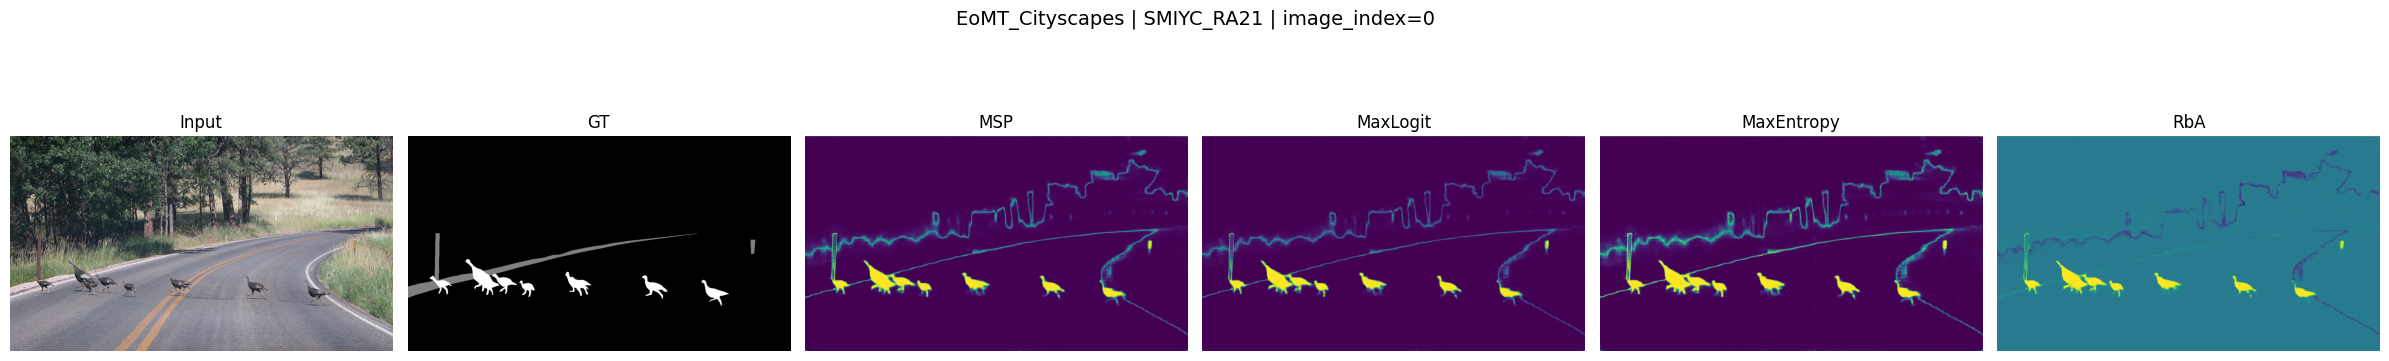

----------------------------------------------------------------------------------------------------
Generating figure for model=EoMT_Cityscapes | dataset=SMIYC_RO21
----------------------------------------------------------------------------------------------------
Saved figure to: /content/outputs_step8/visualizations/EoMT_Cityscapes/SMIYC_RO21_idx0.png


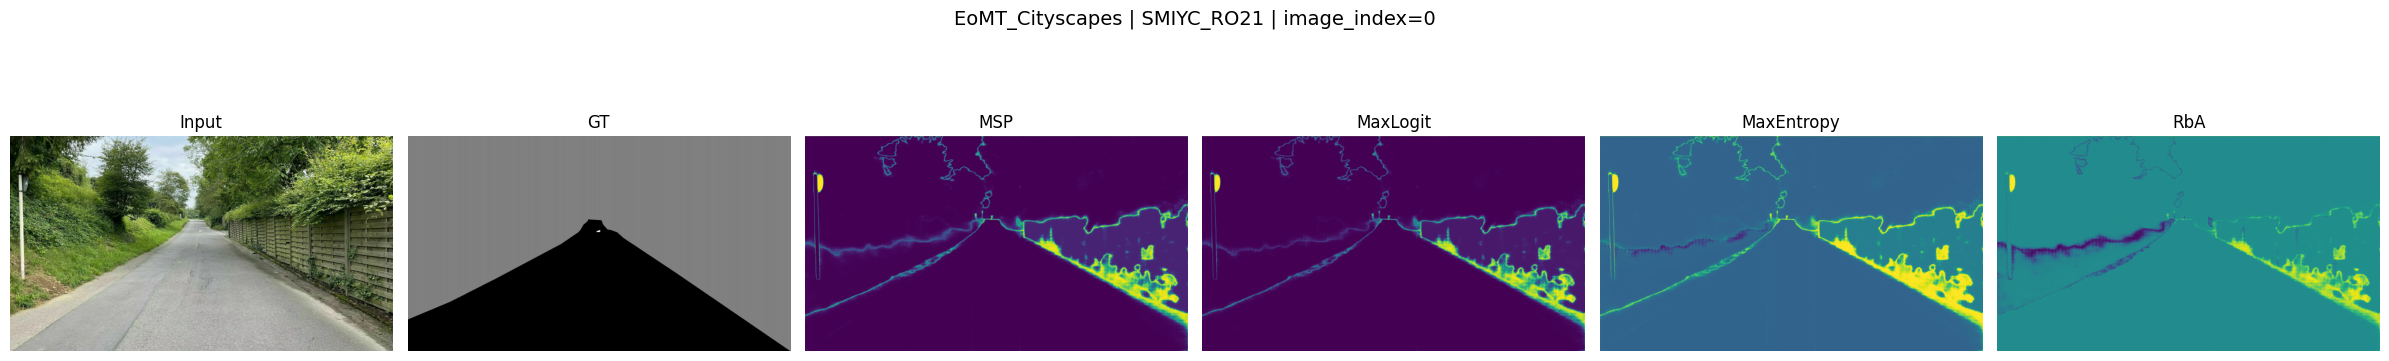

----------------------------------------------------------------------------------------------------
Generating figure for model=EoMT_Cityscapes | dataset=FS_LF
----------------------------------------------------------------------------------------------------
Saved figure to: /content/outputs_step8/visualizations/EoMT_Cityscapes/FS_LF_idx0.png


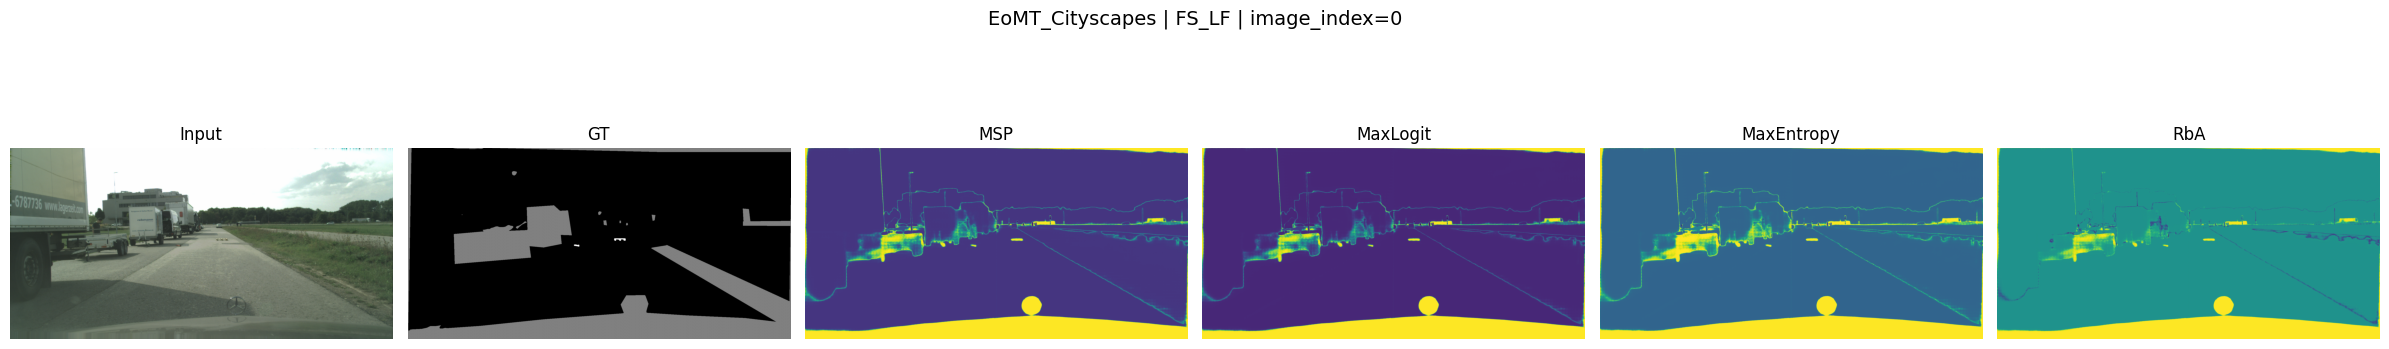

----------------------------------------------------------------------------------------------------
Generating figure for model=EoMT_Cityscapes | dataset=FS_Static
----------------------------------------------------------------------------------------------------
Saved figure to: /content/outputs_step8/visualizations/EoMT_Cityscapes/FS_Static_idx0.png


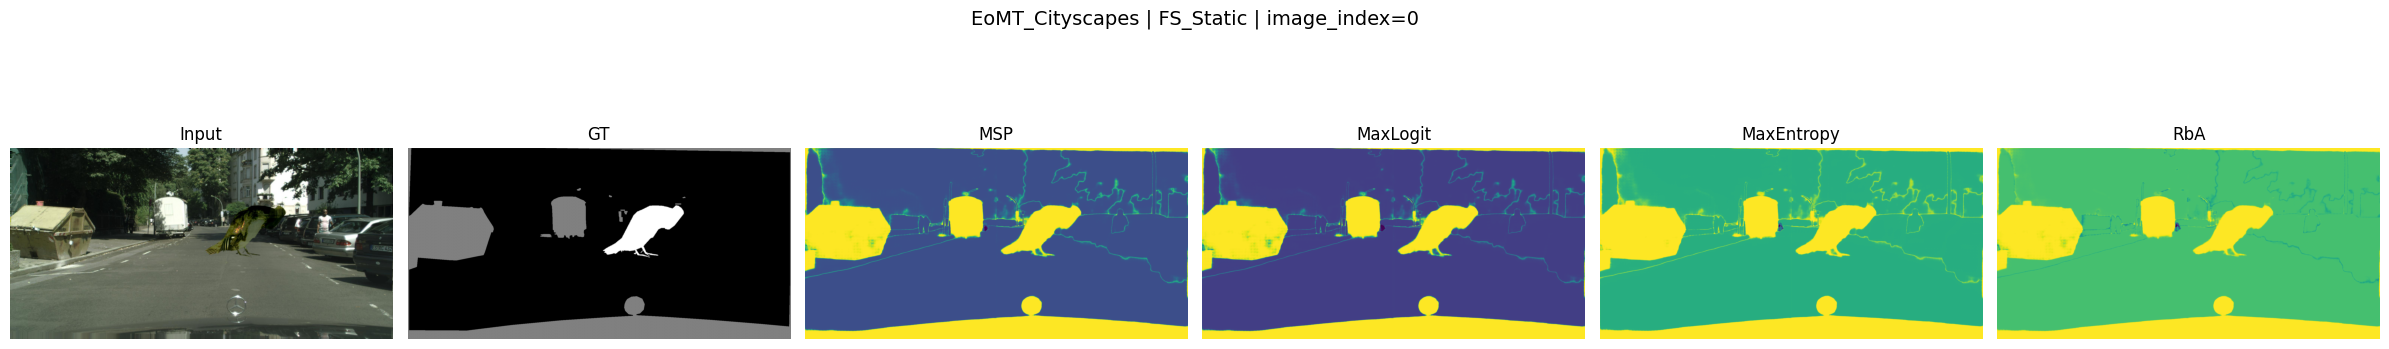

----------------------------------------------------------------------------------------------------
Generating figure for model=EoMT_Cityscapes | dataset=RoadAnomaly
----------------------------------------------------------------------------------------------------
Saved figure to: /content/outputs_step8/visualizations/EoMT_Cityscapes/RoadAnomaly_idx0.png


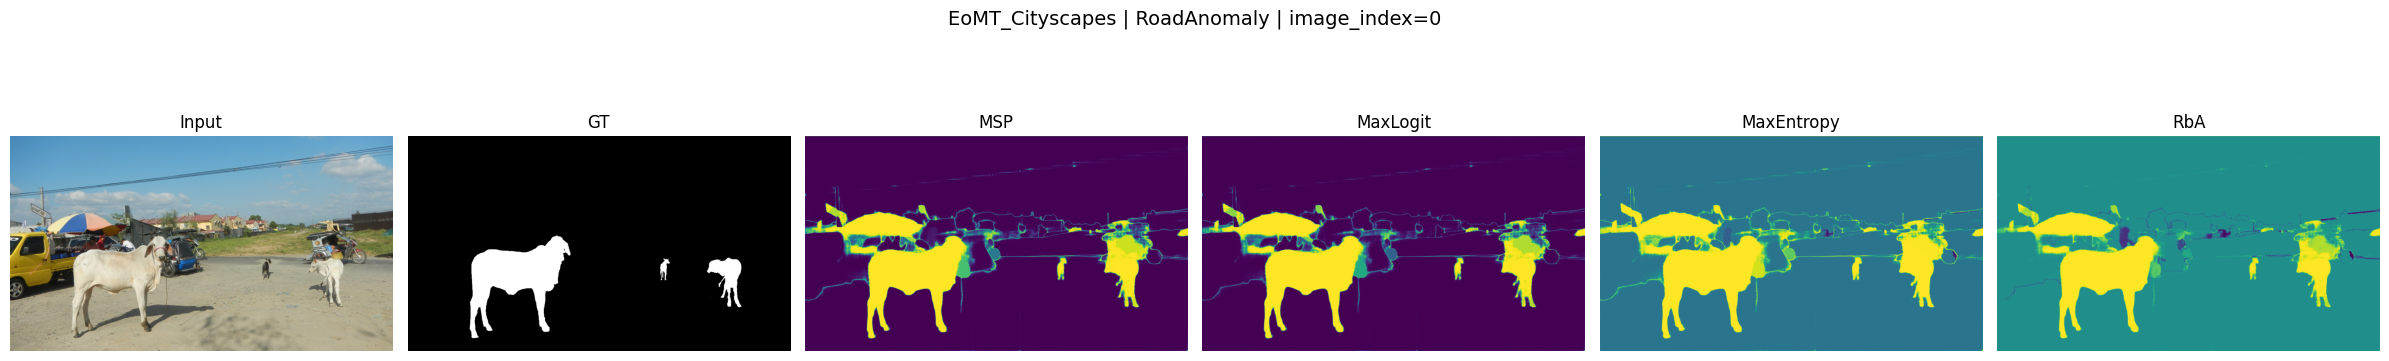

Loading model: EoMT_COCO
Loaded checkpoint: /content/work/eomt_coco.bin
Missing keys: 0
Unexpected keys: 0
----------------------------------------------------------------------------------------------------
Generating figure for model=EoMT_COCO | dataset=SMIYC_RA21
----------------------------------------------------------------------------------------------------
Saved figure to: /content/outputs_step8/visualizations/EoMT_COCO/SMIYC_RA21_idx0.png


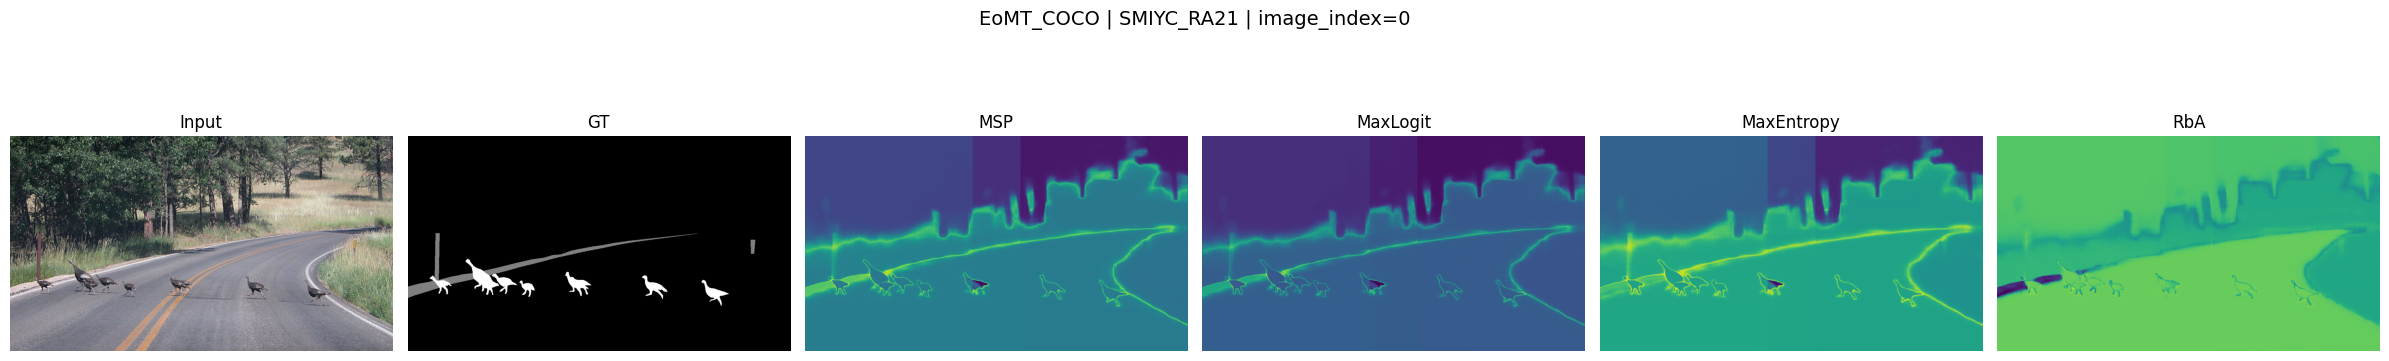

----------------------------------------------------------------------------------------------------
Generating figure for model=EoMT_COCO | dataset=SMIYC_RO21
----------------------------------------------------------------------------------------------------
Saved figure to: /content/outputs_step8/visualizations/EoMT_COCO/SMIYC_RO21_idx0.png


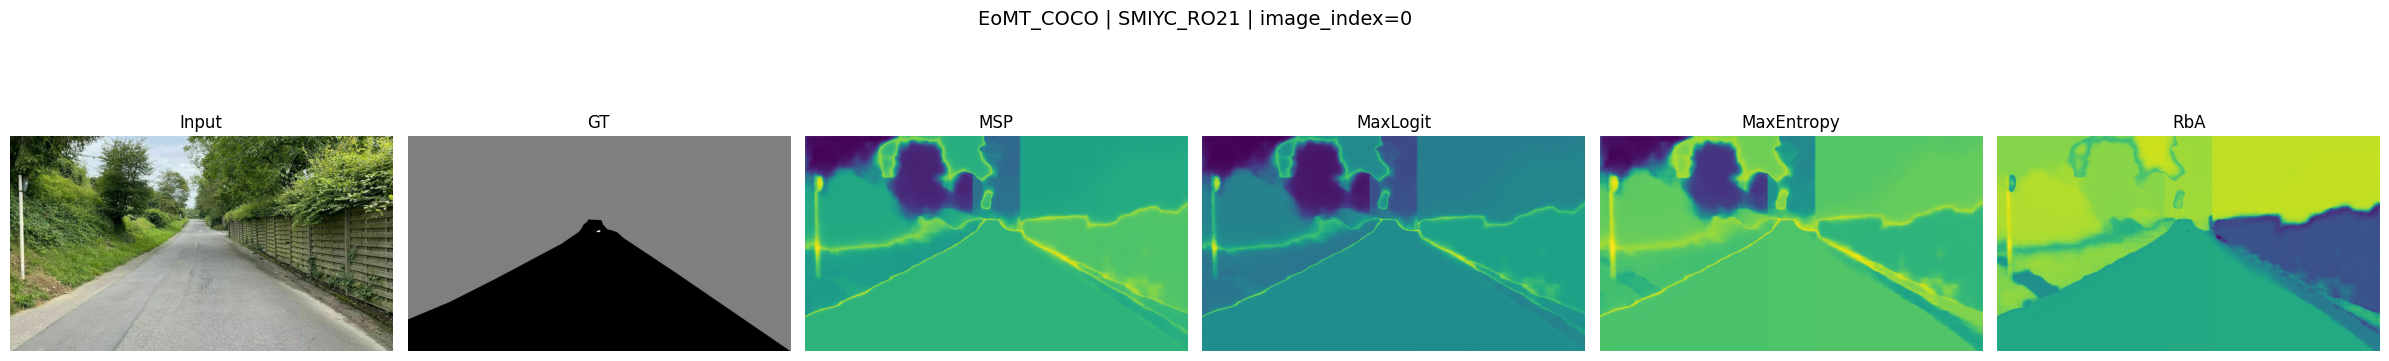

----------------------------------------------------------------------------------------------------
Generating figure for model=EoMT_COCO | dataset=FS_LF
----------------------------------------------------------------------------------------------------
Saved figure to: /content/outputs_step8/visualizations/EoMT_COCO/FS_LF_idx0.png


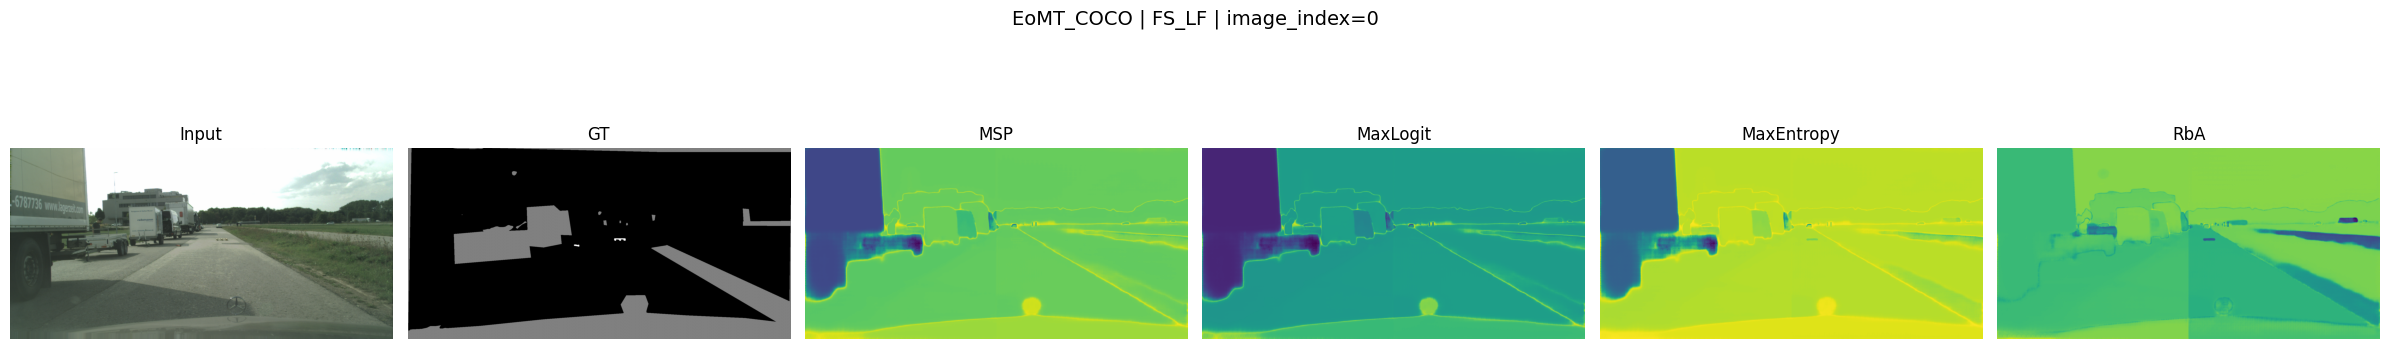

----------------------------------------------------------------------------------------------------
Generating figure for model=EoMT_COCO | dataset=FS_Static
----------------------------------------------------------------------------------------------------
Saved figure to: /content/outputs_step8/visualizations/EoMT_COCO/FS_Static_idx0.png


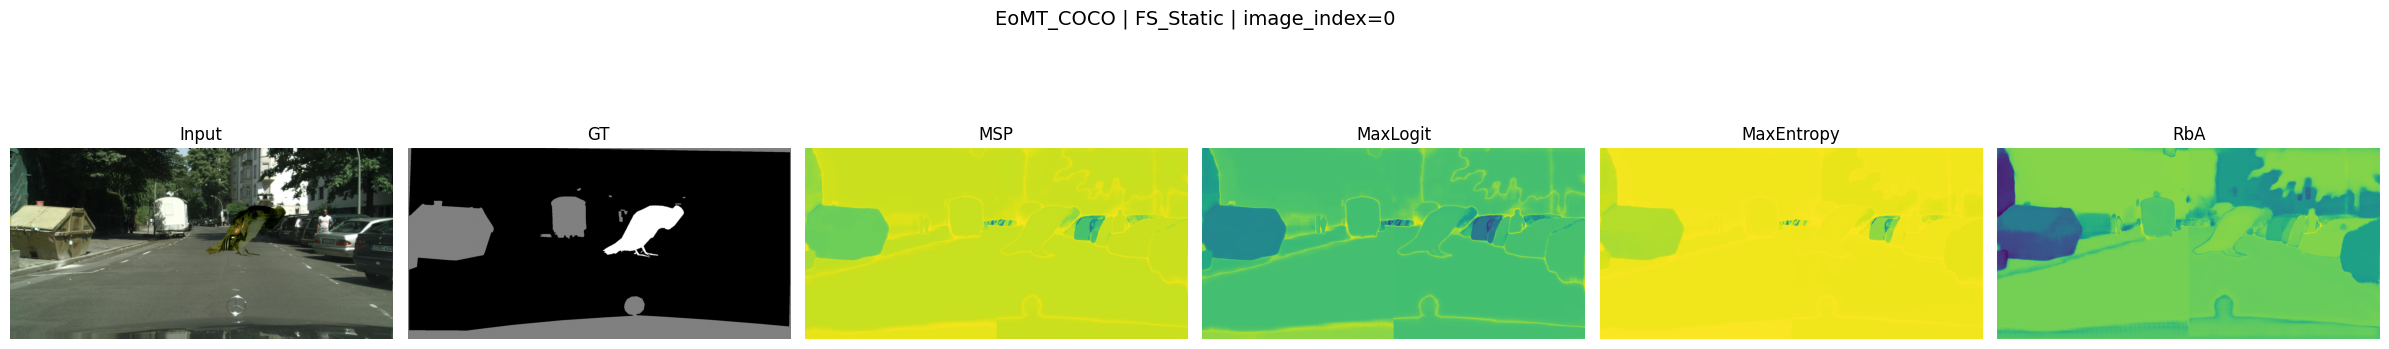

----------------------------------------------------------------------------------------------------
Generating figure for model=EoMT_COCO | dataset=RoadAnomaly
----------------------------------------------------------------------------------------------------
Saved figure to: /content/outputs_step8/visualizations/EoMT_COCO/RoadAnomaly_idx0.png


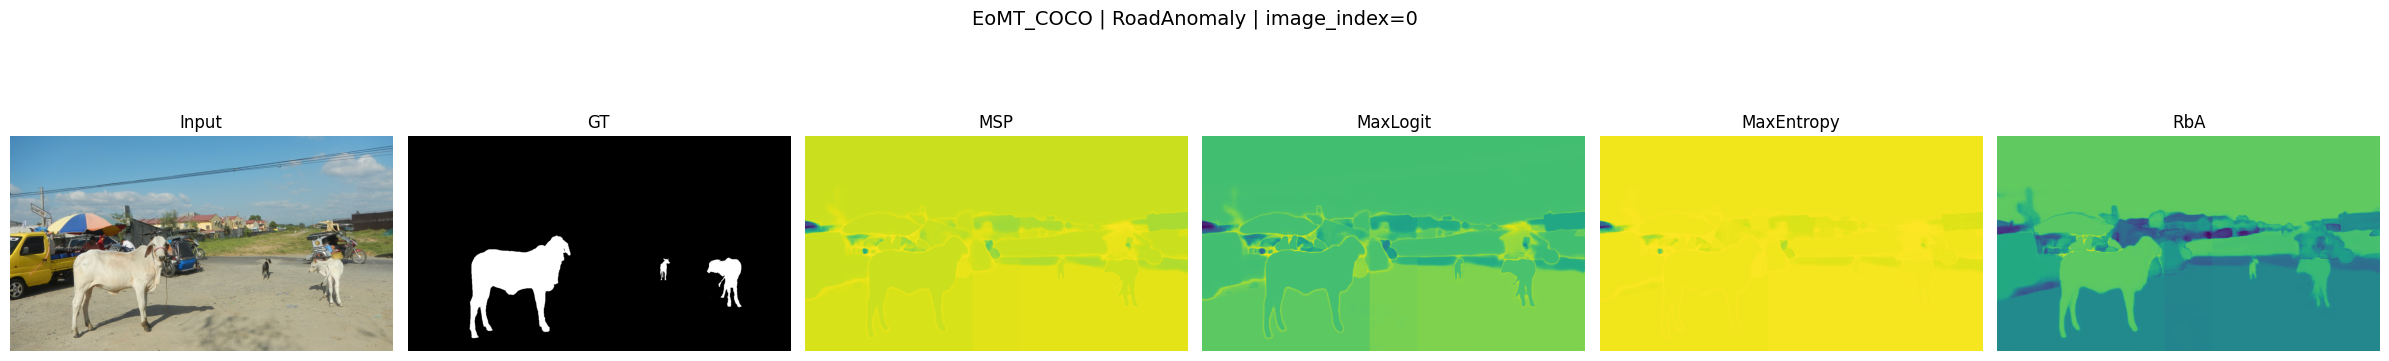

Loading model: EoMT_FineTuned
Loaded checkpoint: /content/work/eomt_finetuned.ckpt
Missing keys: 0
Unexpected keys: 0
----------------------------------------------------------------------------------------------------
Generating figure for model=EoMT_FineTuned | dataset=SMIYC_RA21
----------------------------------------------------------------------------------------------------
Saved figure to: /content/outputs_step8/visualizations/EoMT_FineTuned/SMIYC_RA21_idx0.png


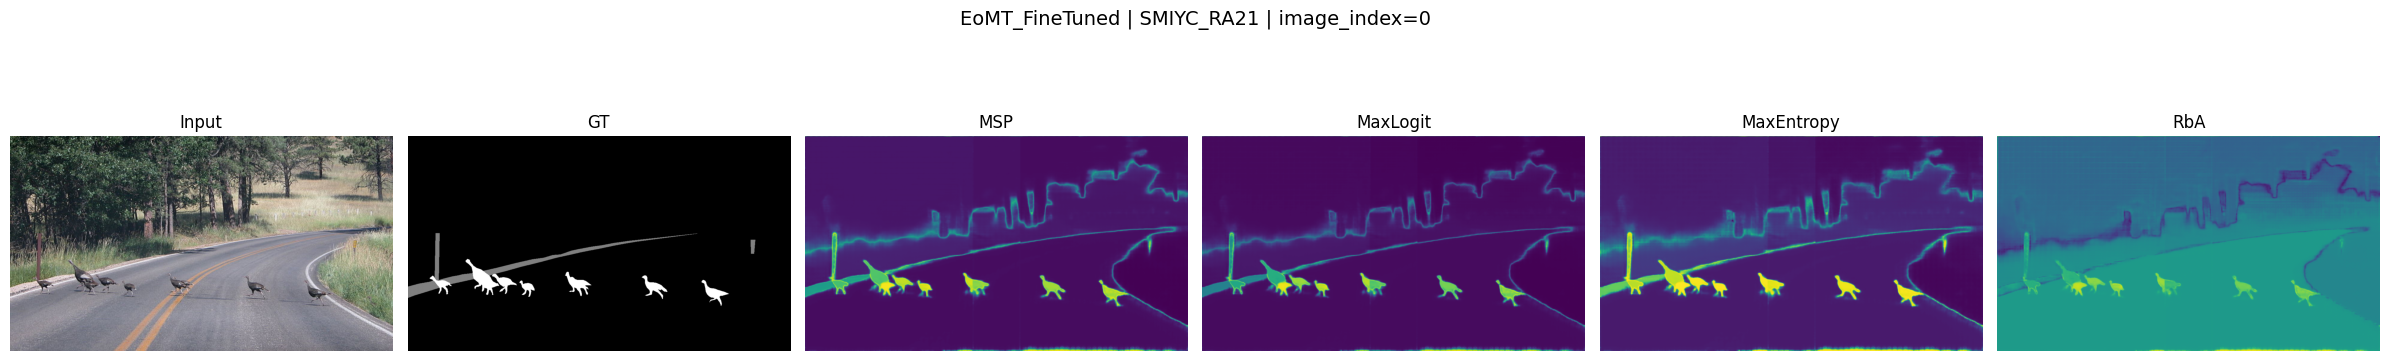

----------------------------------------------------------------------------------------------------
Generating figure for model=EoMT_FineTuned | dataset=SMIYC_RO21
----------------------------------------------------------------------------------------------------
Saved figure to: /content/outputs_step8/visualizations/EoMT_FineTuned/SMIYC_RO21_idx0.png


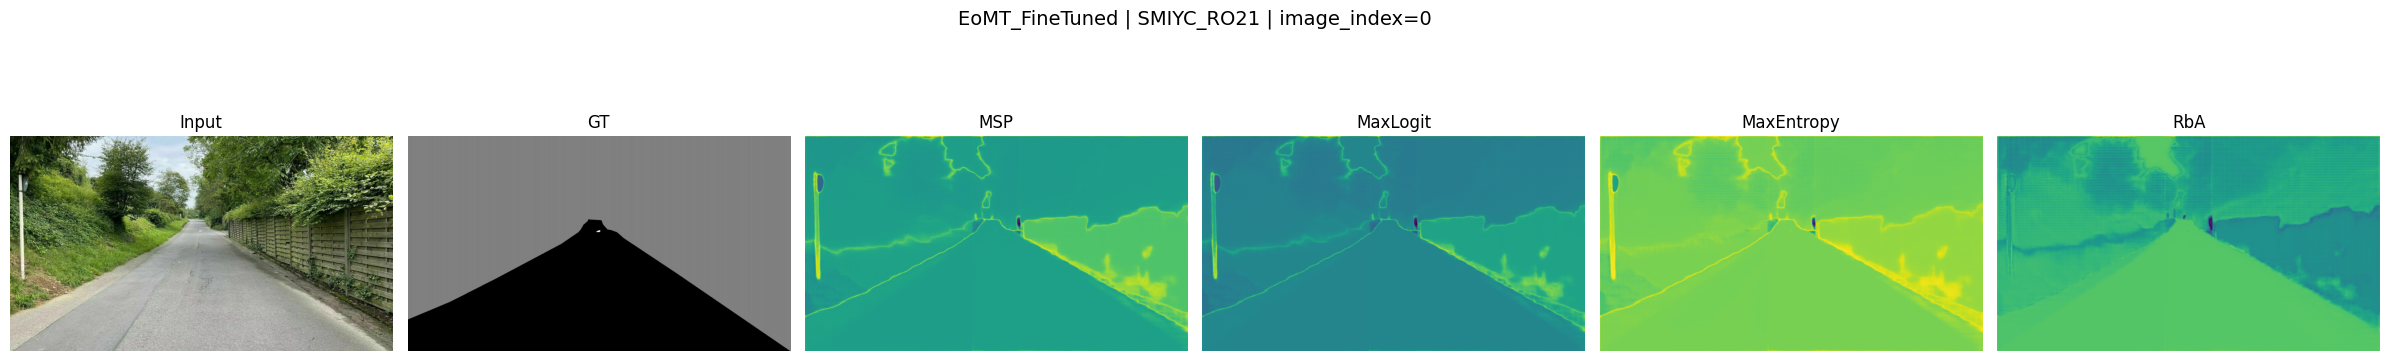

----------------------------------------------------------------------------------------------------
Generating figure for model=EoMT_FineTuned | dataset=FS_LF
----------------------------------------------------------------------------------------------------
Saved figure to: /content/outputs_step8/visualizations/EoMT_FineTuned/FS_LF_idx0.png


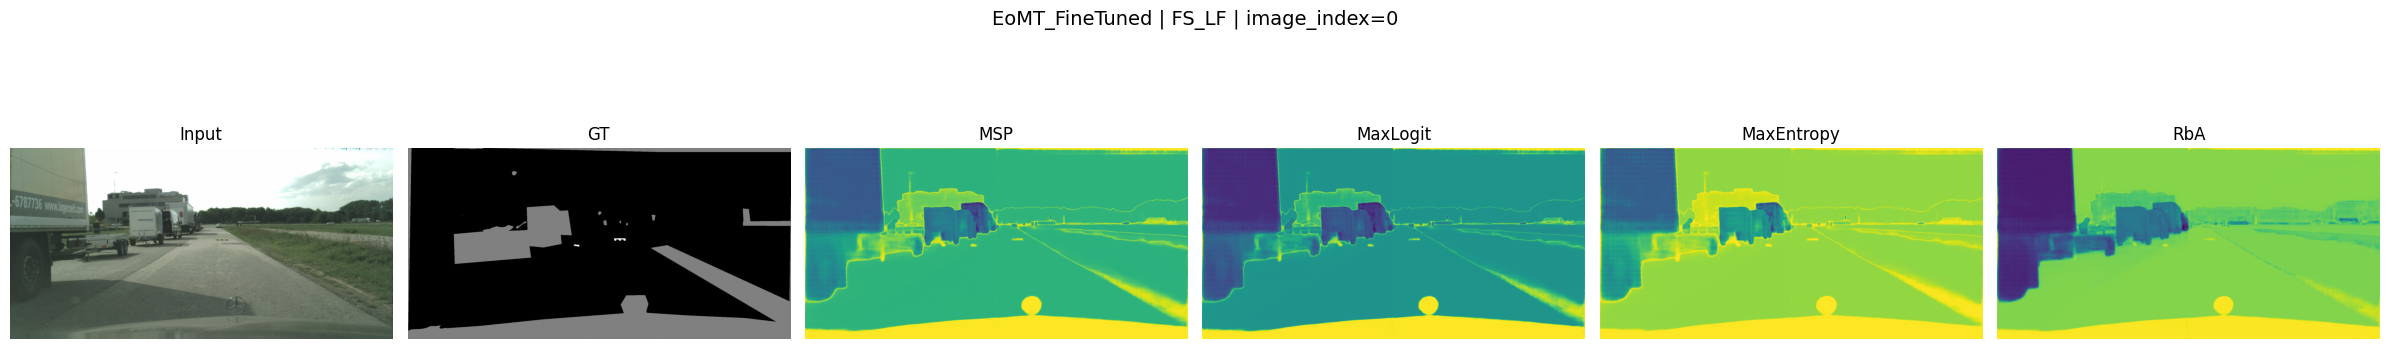

----------------------------------------------------------------------------------------------------
Generating figure for model=EoMT_FineTuned | dataset=FS_Static
----------------------------------------------------------------------------------------------------
Saved figure to: /content/outputs_step8/visualizations/EoMT_FineTuned/FS_Static_idx0.png


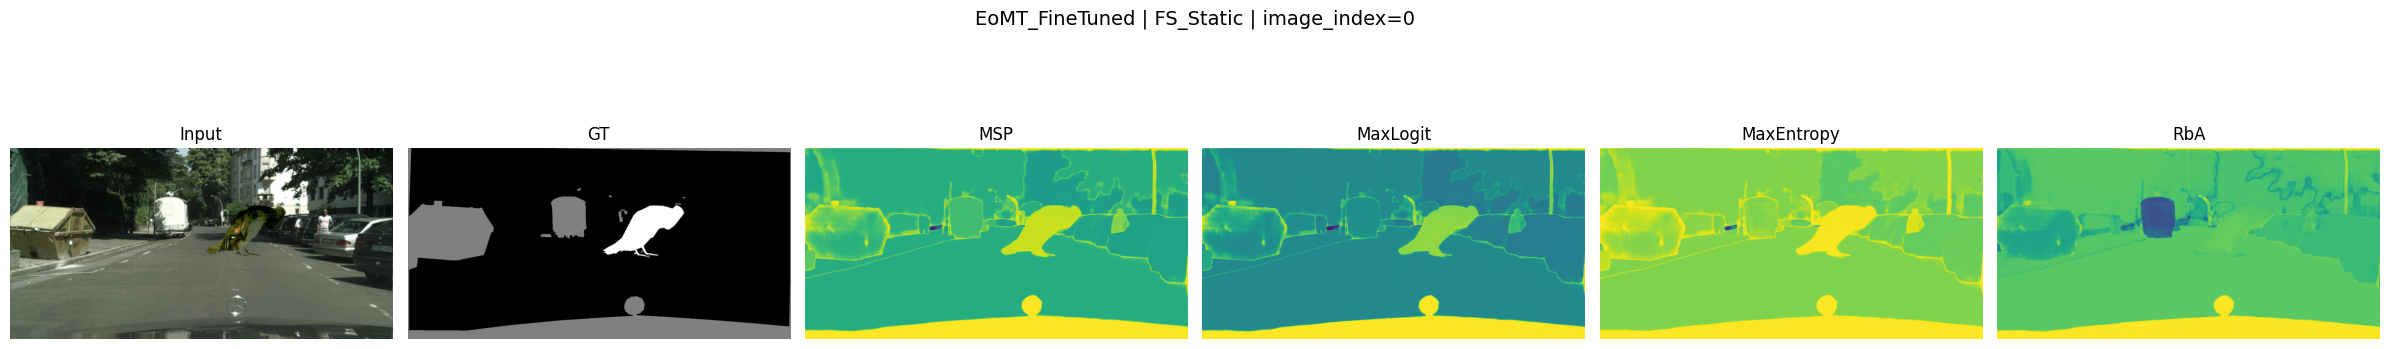

----------------------------------------------------------------------------------------------------
Generating figure for model=EoMT_FineTuned | dataset=RoadAnomaly
----------------------------------------------------------------------------------------------------
Saved figure to: /content/outputs_step8/visualizations/EoMT_FineTuned/RoadAnomaly_idx0.png


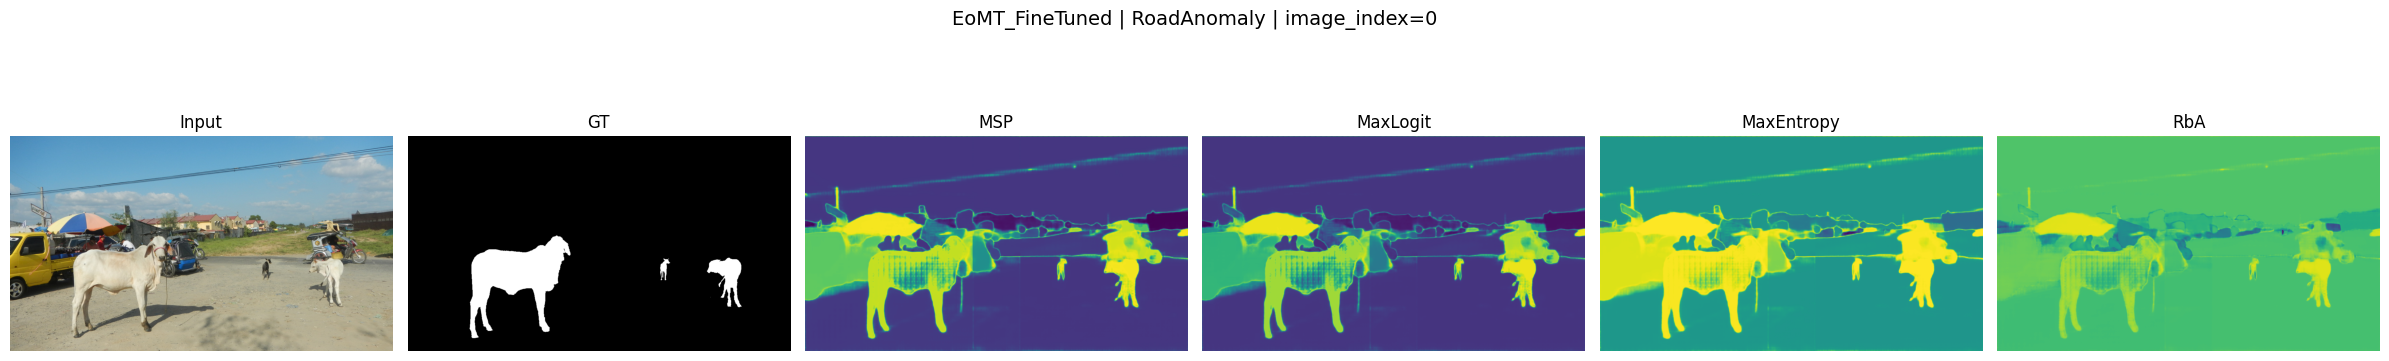


All saved figures:
/content/outputs_step8/visualizations/EoMT_Cityscapes/SMIYC_RA21_idx0.png
/content/outputs_step8/visualizations/EoMT_Cityscapes/SMIYC_RO21_idx0.png
/content/outputs_step8/visualizations/EoMT_Cityscapes/FS_LF_idx0.png
/content/outputs_step8/visualizations/EoMT_Cityscapes/FS_Static_idx0.png
/content/outputs_step8/visualizations/EoMT_Cityscapes/RoadAnomaly_idx0.png
/content/outputs_step8/visualizations/EoMT_COCO/SMIYC_RA21_idx0.png
/content/outputs_step8/visualizations/EoMT_COCO/SMIYC_RO21_idx0.png
/content/outputs_step8/visualizations/EoMT_COCO/FS_LF_idx0.png
/content/outputs_step8/visualizations/EoMT_COCO/FS_Static_idx0.png
/content/outputs_step8/visualizations/EoMT_COCO/RoadAnomaly_idx0.png
/content/outputs_step8/visualizations/EoMT_FineTuned/SMIYC_RA21_idx0.png
/content/outputs_step8/visualizations/EoMT_FineTuned/SMIYC_RO21_idx0.png
/content/outputs_step8/visualizations/EoMT_FineTuned/FS_LF_idx0.png
/content/outputs_step8/visualizations/EoMT_FineTuned/FS_Static_idx

In [ ]:
import os
import gc
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

STEP8_VIS_DIR = f"{OUTPUT_DIR}/visualizations"
os.makedirs(STEP8_VIS_DIR, exist_ok=True)

def _prepare_gt_for_display(gt_array):
    vis = np.zeros_like(gt_array, dtype=np.float32)
    vis[gt_array == 0] = 0.0
    vis[gt_array == 1] = 1.0
    vis[gt_array == 255] = 0.5
    return vis

def _compute_rba_from_logits(logits):
    """
    Compute the RbA anomaly map from semantic logits [C, H, W].
    """
    return (-torch.tanh(logits).sum(dim=0)).cpu().numpy().astype(np.float32)

def compute_eomt_visual_map(logits, method):
    """
    Wrapper used only for visualization.
    """
    method = method.lower()

    if method == "rba":
        return _compute_rba_from_logits(logits)

    return compute_eomt_anomaly_result(logits, method)

def generate_step8_figure(model_name, model, dataset_key, image_index=0,
                          cmap="viridis", save=True, show=True):
    if dataset_key not in ANOMALY_DATASETS:
        raise ValueError(
            f"Unknown dataset_key: {dataset_key}. "
            f"Available keys: {list(ANOMALY_DATASETS.keys())}"
        )

    dataset_root = ANOMALY_DATASETS[dataset_key]
    image_paths = get_image_paths(dataset_root)

    if len(image_paths) == 0:
        raise ValueError(f"No images found for dataset {dataset_key} at path: {dataset_root}")

    if image_index >= len(image_paths):
        raise ValueError(
            f"image_index={image_index} is out of range. "
            f"Dataset has {len(image_paths)} images."
        )

    img_path = image_paths[image_index]
    gt_path = get_mask_path(img_path)

    if not os.path.exists(gt_path):
        raise ValueError(
            f"GT mask not found.\n"
            f"Image path: {img_path}\n"
            f"Expected GT path: {gt_path}"
        )

    # Forward once
    logits = forward_eomt_semantic_logits(model, img_path)   # [C, H, W]

    score_h = logits.shape[1]
    score_w = logits.shape[2]

    # Input image for display
    img_pil = Image.open(img_path).convert("RGB")
    img_pil = img_pil.resize((score_w, score_h), Image.BILINEAR)
    img_vis = np.array(img_pil).astype(np.float32) / 255.0

    # GT for display
    gt_pil = Image.open(gt_path)
    gt_pil = gt_pil.resize((score_w, score_h), Image.NEAREST)
    gt = np.array(gt_pil)
    gt = normalize_ood_mask(gt, gt_path)
    gt_vis = _prepare_gt_for_display(gt)

    # Anomaly maps
    msp_map = compute_eomt_visual_map(logits, "msp")
    maxlogit_map = compute_eomt_visual_map(logits, "maxlogit")
    maxentropy_map = compute_eomt_visual_map(logits, "maxentropy")
    rba_map = compute_eomt_visual_map(logits, "rba")

    # Plot
    fig, axes = plt.subplots(1, 6, figsize=(24, 4.5))

    axes[0].imshow(img_vis)
    axes[0].set_title("Input")
    axes[0].axis("off")

    axes[1].imshow(gt_vis, cmap="gray", vmin=0, vmax=1)
    axes[1].set_title("GT")
    axes[1].axis("off")

    axes[2].imshow(msp_map, cmap=cmap)
    axes[2].set_title("MSP")
    axes[2].axis("off")

    axes[3].imshow(maxlogit_map, cmap=cmap)
    axes[3].set_title("MaxLogit")
    axes[3].axis("off")

    axes[4].imshow(maxentropy_map, cmap=cmap)
    axes[4].set_title("MaxEntropy")
    axes[4].axis("off")

    axes[5].imshow(rba_map, cmap=cmap)
    axes[5].set_title("RbA")
    axes[5].axis("off")

    plt.suptitle(f"{model_name} | {dataset_key} | image_index={image_index}", fontsize=14)
    plt.tight_layout()

    model_out_dir = os.path.join(STEP8_VIS_DIR, model_name)
    os.makedirs(model_out_dir, exist_ok=True)

    out_path = os.path.join(model_out_dir, f"{dataset_key}_idx{image_index}.png")

    if save:
        fig.savefig(out_path, bbox_inches="tight", dpi=200)
        print("Saved figure to:", out_path)

    if show:
        plt.show()
    else:
        plt.close(fig)

    return out_path


def build_city_model_for_step8():
    city_data = build_data_module(city_config, DATA_DIR)
    model = build_model(
        config=city_config,
        ckpt_path=CITY_CKPT_PATH,
        num_classes=city_data.num_classes,
        img_size=city_data.img_size,
    )
    return model

def build_coco_model_for_step8():
    coco_data_module_name, coco_class_name = coco_config["data"]["class_path"].rsplit(".", 1)
    coco_data_module_cls = getattr(importlib.import_module(coco_data_module_name), coco_class_name)
    coco_data_module_kwargs = coco_config["data"].get("init_args", {})

    coco_data = coco_data_module_cls(
        path=DATA_DIR,
        batch_size=1,
        num_workers=0,
        check_empty_targets=False,
        **coco_data_module_kwargs
    )

    model = build_model(
        config=coco_config,
        ckpt_path=COCO_CKPT_PATH,
        num_classes=coco_data.num_classes,
        img_size=coco_data.img_size,
    )
    return model

def build_ft_model_for_step8():
    city_data = build_data_module(city_config, DATA_DIR)

    coco_data_module_name, coco_class_name = coco_config["data"]["class_path"].rsplit(".", 1)
    coco_data_module_cls = getattr(importlib.import_module(coco_data_module_name), coco_class_name)
    coco_data_module_kwargs = coco_config["data"].get("init_args", {})

    coco_data = coco_data_module_cls(
        path=DATA_DIR,
        batch_size=1,
        num_workers=0,
        check_empty_targets=False,
        **coco_data_module_kwargs
    )

    model = build_model(
        config=ft_config,
        ckpt_path=FT_CKPT_PATH,
        num_classes=city_data.num_classes,
        img_size=coco_data.img_size,
    )
    return model


MODEL_BUILDERS = {
    "EoMT_Cityscapes": build_city_model_for_step8,
    "EoMT_COCO": build_coco_model_for_step8,
    "EoMT_FineTuned": build_ft_model_for_step8,
}

saved_paths = []
DEFAULT_IMAGE_INDEX = 0

for model_name, model_builder in MODEL_BUILDERS.items():
    print("=" * 100)
    print(f"Loading model: {model_name}")
    print("=" * 100)

    model = model_builder()

    for dataset_key in ANOMALY_DATASETS.keys():
        print("-" * 100)
        print(f"Generating figure for model={model_name} | dataset={dataset_key}")
        print("-" * 100)

        try:
            out_path = generate_step8_figure(
                model_name=model_name,
                model=model,
                dataset_key=dataset_key,
                image_index=DEFAULT_IMAGE_INDEX,
                cmap="viridis",
                save=True,
                show=True
            )
            saved_paths.append(out_path)

        except Exception as e:
            print(f"Skipping model={model_name}, dataset={dataset_key} because of error: {e}")

    # Free memory before loading the next model
    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("\nAll saved figures:")
for p in saved_paths:
    print(p)


# Temperature scaling on MSP

In [11]:
import importlib

# to build the datamodule without calling setup()
def build_metadata_only(config, data_path):
    """
    Build the datamodule object without calling setup().
    """
    data_module_name, class_name = config["data"]["class_path"].rsplit(".", 1)
    data_module_cls = getattr(importlib.import_module(data_module_name), class_name)
    data_module_kwargs = config["data"].get("init_args", {})

    data_module = data_module_cls(
        path=data_path,
        batch_size=1,
        num_workers=0,
        check_empty_targets=False,
        **data_module_kwargs
    )

    return data_module

Model builders for the 3 checkpoints

In [12]:
import gc
import shutil

# Cityscapes model
def build_city_model_for_temperature():
    city_meta = build_metadata_only(city_config, DATA_DIR)
    model = build_model(
        config=city_config,
        ckpt_path=CITY_CKPT_PATH,
        num_classes=city_meta.num_classes,
        img_size=city_meta.img_size,
    )
    return model

# Coco model
def build_coco_model_for_temperature():
    coco_meta = build_metadata_only(coco_config, DATA_DIR)
    model = build_model(
        config=coco_config,
        ckpt_path=COCO_CKPT_PATH,
        num_classes=coco_meta.num_classes,
        img_size=coco_meta.img_size,
    )
    return model

# Fine-Tuned model
def build_ft_model_for_temperature():
    city_meta = build_metadata_only(city_config, DATA_DIR)
    coco_meta = build_metadata_only(coco_config, DATA_DIR)
    model = build_model(
        config=ft_config,
        ckpt_path=FT_CKPT_PATH,
        num_classes=city_meta.num_classes,
        img_size=coco_meta.img_size,
    )
    return model

TS_MODEL_BUILDERS = {
    "EoMT_Cityscapes": build_city_model_for_temperature,
    "EoMT_COCO": build_coco_model_for_temperature,
    "EoMT_FineTuned": build_ft_model_for_temperature,
}

TS_OUTPUT_DIR = f"{OUTPUT_DIR}/temperature_scaling"
os.makedirs(TS_OUTPUT_DIR, exist_ok=True)
print("Temperature-scaling output dir:", TS_OUTPUT_DIR)


Temperature-scaling output dir: /content/outputs_step8/temperature_scaling


# Cache logits and aligned GT only once

In [13]:

def save_temperature_scaling(model, dataset_key, cache_dir, overwrite=False):
    """
    Run EoMT once on all images of one anomaly dataset and save:
    - semantic logits resized to 512x1024
    - normalized GT mask resized to 512x1024

    This avoids repeating the full forward pass for each temperature value.
    """
    dataset_root = ANOMALY_DATASETS[dataset_key]
    image_paths = get_image_paths(dataset_root)

    dataset_cache_dir = os.path.join(cache_dir, dataset_key)

    if overwrite and os.path.exists(dataset_cache_dir):
        shutil.rmtree(dataset_cache_dir)

    os.makedirs(dataset_cache_dir, exist_ok=True)

    existing_files = sorted(glob.glob(os.path.join(dataset_cache_dir, "*.npz")))  # .npz --> to save compressed Numpy arrays
    if len(existing_files) == len(image_paths) and len(existing_files) > 0:
        print(f"Cache already available for {dataset_key}: {len(existing_files)} files")
        return

    print(f"Saving cache for dataset: {dataset_key}")
    print(f"Images found: {len(image_paths)}")

    saved = 0

    for idx, path in enumerate(image_paths):
        pathGT = get_mask_path(path)

        if not os.path.exists(pathGT):
            print("Missing GT:", pathGT)
            continue

        # EoMT forward -> semantic logits [C, H, W]
        logits = forward_eomt_semantic_logits(model, path)

        # Resize logits to the common evaluation resolution
        logits_4d = logits.unsqueeze(0)  # [1, C, H, W]
        logits_resized = F.interpolate(
            logits_4d,
            size=(512, 1024),
            mode="bilinear",
            align_corners=False
        ).squeeze(0).cpu().numpy().astype(np.float32)

        # Load and resize GT to the same resolution
        mask = Image.open(pathGT)
        mask = mask.resize((1024, 512), Image.NEAREST)
        ood_gts = np.array(mask)
        ood_gts = normalize_ood_mask(ood_gts, pathGT).astype(np.uint8)

        out_path = os.path.join(dataset_cache_dir, f"sample_{idx:04d}.npz")
        np.savez_compressed(
            out_path,
            logits=logits_resized,
            gt=ood_gts,
            img_path=path
        )
        saved += 1

        del logits, logits_4d, logits_resized, mask, ood_gts
        torch.cuda.empty_cache()

    print(f"Saved {saved} cached samples for {dataset_key}")


# MSP with temperature scaling

In [14]:

def compute_msp_with_temperature(logits_np, temperature=1.0):
    """
    logits_np: numpy array of shape [C, H, W]
    temperature: scalar T

    From the provided temperature_scaling.py: logits are divided by T before softmax.
    """
    logits = torch.from_numpy(logits_np)
    scaled_logits = logits / float(temperature)
    probs = torch.softmax(scaled_logits, dim=0)
    anomaly_result = 1.0 - torch.max(probs, dim=0).values
    return anomaly_result.cpu().numpy().astype(np.float32)


# Evaluate MSP on one cached dataset

In [15]:

def evaluate_temperature_scaled_dataset(dataset_key, cache_dir, temperature=1.0):
    """
    Evaluate MSP with a given temperature on one cached dataset
    """
    dataset_cache_dir = os.path.join(cache_dir, dataset_key)
    sample_files = sorted(glob.glob(os.path.join(dataset_cache_dir, "*.npz")))

    anomaly_score_list = []
    ood_gts_list = []

    print(f"Dataset: {dataset_key} | T = {temperature}")
    print(f"Cached samples found: {len(sample_files)}")

    for sample_path in sample_files:
        data = np.load(sample_path, allow_pickle=True)
        logits_np = data["logits"]   # [C, 512, 1024]
        ood_gts = data["gt"]         # [512, 1024]

        if 1 not in np.unique(ood_gts):
            continue

        anomaly_result = compute_msp_with_temperature(
            logits_np,
            temperature=temperature
        )

        valid_mask = (ood_gts != 255)
        ood_gts_valid = ood_gts[valid_mask]
        anomaly_valid = anomaly_result[valid_mask]

        ood_mask = (ood_gts_valid == 1)
        ind_mask = (ood_gts_valid == 0)

        ood_out = anomaly_valid[ood_mask]
        ind_out = anomaly_valid[ind_mask]

        if len(ood_out) == 0 or len(ind_out) == 0:
            continue

        anomaly_score_list.append(anomaly_valid)
        ood_gts_list.append(ood_gts_valid)

    if len(ood_gts_list) == 0:
        return {
            "AUPRC": np.nan,
            "FPR95": np.nan,
            "num_images_used": 0
        }

    ood_gts_all = np.concatenate(ood_gts_list)
    anomaly_all = np.concatenate(anomaly_score_list)

    ood_mask = (ood_gts_all == 1)
    ind_mask = (ood_gts_all == 0)

    ood_out = anomaly_all[ood_mask]
    ind_out = anomaly_all[ind_mask]

    if len(ood_out) == 0 or len(ind_out) == 0:
        return {
            "AUPRC": np.nan,
            "FPR95": np.nan,
            "num_images_used": len(ood_gts_list)
        }

    val_out = np.concatenate((ind_out, ood_out))
    val_label = np.concatenate((np.zeros(len(ind_out)), np.ones(len(ood_out))))

    prc_auc = average_precision_score(val_label, val_out)
    fpr = fpr_at_95_tpr(val_out, val_label)

    return {
        "AUPRC": float(prc_auc * 100.0),
        "FPR95": float(fpr * 100.0),
        "num_images_used": int(len(ood_gts_list))
    }

def score_temperature_row(row):
    """
    Higher AUPRC is better, lower FPR95 is better.
    We use mean(AUPRC) - mean(FPR95) as a simple ranking score.
    """
    auprc_cols = [c for c in row.index if "AuPRC" in c]
    fpr_cols = [c for c in row.index if "FPR95" in c]

    mean_auprc = np.nanmean([row[c] for c in auprc_cols])
    mean_fpr = np.nanmean([row[c] for c in fpr_cols])

    return mean_auprc - mean_fpr


# Run the full temperature-scaling pipeline for one checkpoint

In [ ]:

def run_temperature_scaling(
    model_name,
    model_builder,
    candidate_temperatures=(0.1, 0.2, 0.3, 0.4, 0.5, 0.75, 1.25, 1.5, 2.0, 3.0, 5.0),
):
    """
    Run temperature scaling only for MSP on one checkpoint.

    Notes:
    - We cache logits once per dataset to avoid repeated EoMT forward passes.
    - We only evaluate the candidate temperatures listed above.
    - The returned table contains all tested temperatures and a global score
      used to rank them.
    """

    print("=" * 100)
    print(f"Temperature scaling for: {model_name}")
    print("=" * 100)

    model = model_builder()
    cache_dir = os.path.join(TS_OUTPUT_DIR, model_name, "cache")
    os.makedirs(cache_dir, exist_ok=True)

    # Cache logits only once for this checkpoint
    for dataset_key in ANOMALY_DATASETS.keys():
        save_temperature_scaling(
            model=model,
            dataset_key=dataset_key,
            cache_dir=cache_dir,
            overwrite=False
        )

    # Evaluate all candidate temperatures and store every configuration
    search_rows = []

    for T in candidate_temperatures:
        row = {
            "Model": model_name,
            "Method": f"MSP(T={T})",
            "Temperature": T,
        }

        for dataset_key in ANOMALY_DATASETS.keys():
            result = evaluate_temperature_scaled_dataset(
                dataset_key=dataset_key,
                cache_dir=cache_dir,
                temperature=T
            )

            display_name = {
                "SMIYC_RA21": "SMIYC RA-21",
                "SMIYC_RO21": "SMIYC RO-21",
                "FS_LF": "FS L&F",
                "FS_Static": "FS Static",
                "RoadAnomaly": "Road Anomaly",
            }[dataset_key]

            row[f"{display_name} AuPRC"] = result["AUPRC"]
            row[f"{display_name} FPR95"] = result["FPR95"]

        search_rows.append(row)

    search_df = pd.DataFrame(search_rows)
    search_df["score"] = search_df.apply(score_temperature_row, axis=1)
    search_df = search_df.sort_values("score", ascending=False).reset_index(drop=True)

    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return search_df


# Temperature scaling search: Cityscapes checkpoint

In [17]:

ts_city_search_df = run_temperature_scaling(
    model_name="EoMT_Cityscapes",
    model_builder=TS_MODEL_BUILDERS["EoMT_Cityscapes"],
)

ts_city_search_df


Temperature scaling for: EoMT_Cityscapes
Loaded checkpoint: /content/drive/MyDrive/Project-FAIMDL/downloads/models/cityscapes/eomt_cityscapes.bin
Missing keys: 0
Unexpected keys: 0
Cache already available for SMIYC_RA21: 10 files
Cache already available for SMIYC_RO21: 30 files
Saving cache for dataset: FS_LF
Images found: 100
Saved 100 cached samples for FS_LF
Saving cache for dataset: FS_Static
Images found: 30
Saved 30 cached samples for FS_Static
Saving cache for dataset: RoadAnomaly
Images found: 60
Saved 60 cached samples for RoadAnomaly
Dataset: SMIYC_RA21 | T = 0.5
Cached samples found: 10
Dataset: SMIYC_RO21 | T = 0.5
Cached samples found: 30
Dataset: FS_LF | T = 0.5
Cached samples found: 100
Dataset: FS_Static | T = 0.5
Cached samples found: 30
Dataset: RoadAnomaly | T = 0.5
Cached samples found: 60
Dataset: SMIYC_RA21 | T = 0.75
Cached samples found: 10
Dataset: SMIYC_RO21 | T = 0.75
Cached samples found: 30
Dataset: FS_LF | T = 0.75
Cached samples found: 100
Dataset: FS_Sta

,Model,Method,Temperature,mIoU,SMIYC RA-21 AuPRC,SMIYC RA-21 FPR95,SMIYC RO-21 AuPRC,SMIYC RO-21 FPR95,FS L&F AuPRC,FS L&F FPR95,FS Static AuPRC,FS Static FPR95,Road Anomaly AuPRC,Road Anomaly FPR95,score
0,EoMT_Cityscapes,MSP(T=5.0),5.00,----,69.384728,30.375019,94.216153,0.369329,16.418991,12.996789,57.945780,41.242173,72.859841,15.537896,42.060857
1,EoMT_Cityscapes,MSP(T=3.0),3.00,----,69.238295,30.374638,94.214984,0.369554,16.399671,12.990494,57.952922,41.429943,72.709218,15.549400,41.960212
2,EoMT_Cityscapes,MSP(T=2.0),2.00,----,69.124572,30.374219,94.213393,0.369453,16.383389,12.991620,57.958582,41.642153,72.605706,15.564009,41.868838
3,EoMT_Cityscapes,MSP(T=1.5),1.50,----,69.047943,30.373746,94.211590,0.369536,16.375626,12.992757,57.955835,41.568290,72.533044,15.580296,41.847883
4,EoMT_Cityscapes,MSP(T=1.25),1.25,----,69.003450,30.372137,94.210108,0.369784,16.371358,12.993767,57.953957,41.590508,72.485343,15.594278,41.820749
5,EoMT_Cityscapes,MSP(T=0.75),0.75,----,68.898097,30.370268,94.203221,0.371068,16.360775,12.997238,57.944615,41.631080,72.349507,15.665975,41.744117
6,EoMT_Cityscapes,MSP(T=0.5),0.50,----,68.836077,30.367993,94.192990,0.373014,16.353119,13.001255,57.927364,41.628938,72.240923,15.821309,41.671593


# Temperature scaling search: COCO checkpoint

In [18]:

ts_coco_search_df = run_temperature_scaling(
    model_name="EoMT_COCO",
    model_builder=TS_MODEL_BUILDERS["EoMT_COCO"],
)

ts_coco_search_df


Temperature scaling for: EoMT_COCO
Loaded checkpoint: /content/drive/MyDrive/Project-FAIMDL/downloads/models/coco/eomt_coco.bin
Missing keys: 0
Unexpected keys: 0
Saving cache for dataset: SMIYC_RA21
Images found: 10
Saved 10 cached samples for SMIYC_RA21
Saving cache for dataset: SMIYC_RO21
Images found: 30
Saved 30 cached samples for SMIYC_RO21
Saving cache for dataset: FS_LF
Images found: 100
Saved 100 cached samples for FS_LF
Saving cache for dataset: FS_Static
Images found: 30
Saved 30 cached samples for FS_Static
Saving cache for dataset: RoadAnomaly
Images found: 60
Saved 60 cached samples for RoadAnomaly
Dataset: SMIYC_RA21 | T = 0.5
Cached samples found: 10
Dataset: SMIYC_RO21 | T = 0.5
Cached samples found: 30
Dataset: FS_LF | T = 0.5
Cached samples found: 100
Dataset: FS_Static | T = 0.5
Cached samples found: 30
Dataset: RoadAnomaly | T = 0.5
Cached samples found: 60
Dataset: SMIYC_RA21 | T = 0.75
Cached samples found: 10
Dataset: SMIYC_RO21 | T = 0.75
Cached samples found: 

,Model,Method,Temperature,mIoU,SMIYC RA-21 AuPRC,SMIYC RA-21 FPR95,SMIYC RO-21 AuPRC,SMIYC RO-21 FPR95,FS L&F AuPRC,FS L&F FPR95,FS Static AuPRC,FS Static FPR95,Road Anomaly AuPRC,Road Anomaly FPR95,score
0,EoMT_COCO,MSP(T=5.0),5.00,----,38.983909,77.326116,2.806296,99.979705,3.794088,97.236814,4.716059,99.439148,18.915892,91.767526,-79.306613
1,EoMT_COCO,MSP(T=3.0),3.00,----,38.955743,77.347646,2.805035,99.979671,3.793020,97.237603,4.712734,99.440345,18.907466,91.777879,-79.321829
2,EoMT_COCO,MSP(T=2.0),2.00,----,38.927700,77.379768,2.803624,99.979651,3.791987,97.238456,4.709079,99.441891,18.900043,91.790916,-79.339650
3,EoMT_COCO,MSP(T=1.5),1.50,----,38.876549,77.415243,2.802279,99.979630,3.791029,97.239581,4.707272,99.443518,18.891631,91.805645,-79.362971
4,EoMT_COCO,MSP(T=1.25),1.25,----,38.867639,77.447489,2.800938,99.979589,3.790228,97.240418,4.705729,99.444985,18.884943,91.817179,-79.376036
5,EoMT_COCO,MSP(T=0.75),0.75,----,38.753225,77.628515,2.794798,99.979464,3.786521,97.247804,4.700334,99.453374,18.854229,91.871058,-79.458222
6,EoMT_COCO,MSP(T=0.5),0.50,----,38.547046,78.189026,2.785459,99.979133,3.780533,97.265006,4.692877,99.469927,18.808692,91.988565,-79.655410


# Temperature scaling search: fine-tuned checkpoint

In [19]:

ts_ft_search_df = run_temperature_scaling(
    model_name="EoMT_FineTuned",
    model_builder=TS_MODEL_BUILDERS["EoMT_FineTuned"],
)

ts_ft_search_df


Temperature scaling for: EoMT_FineTuned
Loaded checkpoint: /content/drive/MyDrive/Project-FAIMDL/downloads/checkpoints/best-epoch=23-metrics/val_iou_all=0.7884.ckpt
Missing keys: 0
Unexpected keys: 0
Saving cache for dataset: SMIYC_RA21
Images found: 10
Saved 10 cached samples for SMIYC_RA21
Saving cache for dataset: SMIYC_RO21
Images found: 30
Saved 30 cached samples for SMIYC_RO21
Saving cache for dataset: FS_LF
Images found: 100
Saved 100 cached samples for FS_LF
Saving cache for dataset: FS_Static
Images found: 30
Saved 30 cached samples for FS_Static
Saving cache for dataset: RoadAnomaly
Images found: 60
Saved 60 cached samples for RoadAnomaly
Dataset: SMIYC_RA21 | T = 0.5
Cached samples found: 10
Dataset: SMIYC_RO21 | T = 0.5
Cached samples found: 30
Dataset: FS_LF | T = 0.5
Cached samples found: 100
Dataset: FS_Static | T = 0.5
Cached samples found: 30
Dataset: RoadAnomaly | T = 0.5
Cached samples found: 60
Dataset: SMIYC_RA21 | T = 0.75
Cached samples found: 10
Dataset: SMIYC_R

,Model,Method,Temperature,mIoU,SMIYC RA-21 AuPRC,SMIYC RA-21 FPR95,SMIYC RO-21 AuPRC,SMIYC RO-21 FPR95,FS L&F AuPRC,FS L&F FPR95,FS Static AuPRC,FS Static FPR95,Road Anomaly AuPRC,Road Anomaly FPR95,score
0,EoMT_FineTuned,MSP(T=0.3),0.30,----,68.339393,65.816528,76.722269,0.698166,36.522050,12.763643,84.866661,15.893429,71.175264,18.828018,44.725171
1,EoMT_FineTuned,MSP(T=0.2),0.20,----,68.030238,65.404105,76.692588,0.702907,36.469763,12.789520,84.781580,15.002430,71.144731,19.604765,44.723035
2,EoMT_FineTuned,MSP(T=0.1),0.10,----,66.648455,63.852523,76.465855,0.717604,36.145989,12.852898,84.370888,14.732363,71.025765,20.449677,44.410377
3,EoMT_FineTuned,MSP(T=0.4),0.40,----,68.479144,68.279554,76.731914,0.696717,36.544259,12.747811,84.895260,15.959331,71.186516,18.747053,44.281325
4,EoMT_FineTuned,MSP(T=0.75),0.75,----,68.582648,68.648088,76.744921,0.695164,36.575408,12.659312,84.921140,16.001031,71.202657,18.642551,44.276125
5,EoMT_FineTuned,MSP(T=0.5),0.50,----,68.556003,68.516263,76.737667,0.695972,36.556766,12.689916,84.906862,15.973740,71.193424,18.717055,44.271555
6,EoMT_FineTuned,MSP(T=5.0),5.00,----,68.656468,68.819745,76.763878,0.693922,36.647023,12.828839,84.940638,16.023593,71.247541,18.572409,44.263408
7,EoMT_FineTuned,MSP(T=1.25),1.25,----,68.592504,68.738825,76.751111,0.694502,36.597582,12.734785,84.926396,16.006908,71.214159,18.599561,44.261434
8,EoMT_FineTuned,MSP(T=3.0),3.00,----,68.626444,68.800983,76.758274,0.694067,36.637311,12.829851,84.935647,16.021345,71.235159,18.577486,44.253821
9,EoMT_FineTuned,MSP(T=1.5),1.50,----,68.595989,68.757203,76.752429,0.694316,36.606871,12.791762,84.929198,16.010568,71.215739,18.592711,44.250733
